In [1]:
from MyPlotRecipe.SharedX import ShareXaxis
from MyPlotRecipe.UniversalColor import UniversalColor
from MyPlotRecipe.legend_shadow import legend_shadow
import numpy as np
import math

from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import FixedLocator

from CSField import CSField
import JupiterMag as jm

jm.Internal.Config(Model='jrm33', CartesianIn=True,
                   CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

UC = UniversalColor()
UC.set_palette()

Importing Library
done


In [2]:
def day2hhmm(decimal_day):
    doy = int(decimal_day)
    rest = decimal_day - doy

    hours = int(rest*24)
    minutes = (rest*24-hours)*60

    if round(minutes) >= 60:
        hours += 1
        minutes = 0
    else:
        minutes = round(minutes)
    return hours, minutes


def hhmm2day(hours, minutes, seconds=0):
    fraction_of_day = hours/24 + minutes/(60*24) + seconds/(60*60*24)
    return fraction_of_day


def fmt_hhmm(decimal_day):
    hours, minutes = day2hhmm(decimal_day)
    hh = '{:02}'.format(hours)
    mm = '{:02}'.format(minutes)
    return hh+':'+mm

In [3]:
# Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                        7, 8, 9, 10, 11,
                        12, 13, 14, 15, 16,
                        17, 18, 19, 20, 21,
                        22, 23, 24], dtype=int)

# Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])

# Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [4]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

# PJ6のデータを読み込む

In [5]:
PJ_num = 6
date_list = ['2017DOY137', '2017DOY138',
             '2017DOY139', '2017DOY140',
             '2017DOY141',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

In [6]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# ======================
# Con2020 original value
jm.Con2020.Config(
    mu_i=con20_mu_i_tot[np.where(con20_pj_idx == 6)],
    i_rho=con20_mu_i_rho[np.where(con20_pj_idx == 6)],
)
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

Distance [RJ]: 35.08238783416442 39.84164981951006


In [31]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 2.3E-4   # [MA m-1]
    csfield.config(
        I_rho=con20_mu_i_rho[np.where(con20_pj_idx == 6)][0],
        I_phi=I_phi_0*f_i,
        c1=12.6,
        c2=20.7,
        c3=26.0,
        c4=45.0,
        w1=-0.20,
        w2=2.18,
        w3=-1.95,
        w4=0.29,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [32]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr1_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta1_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi1_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
4.851566964944908
4.75471036220318
1.9551605034560333
4.111756190790298
3.6679546173828204
3.5617332874534124
Outbound
2.80309335657499
3.196437260140285
3.8462840866957686


In [33]:
print(np.argsort(abs(r_pc-8.0)))

[1797 1433 1432 ... 3591 3592 3593]


In [34]:
print(r_pc[3152])

34.00816246745408


In [35]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(58, 2)
[ 32.        137.3107755]


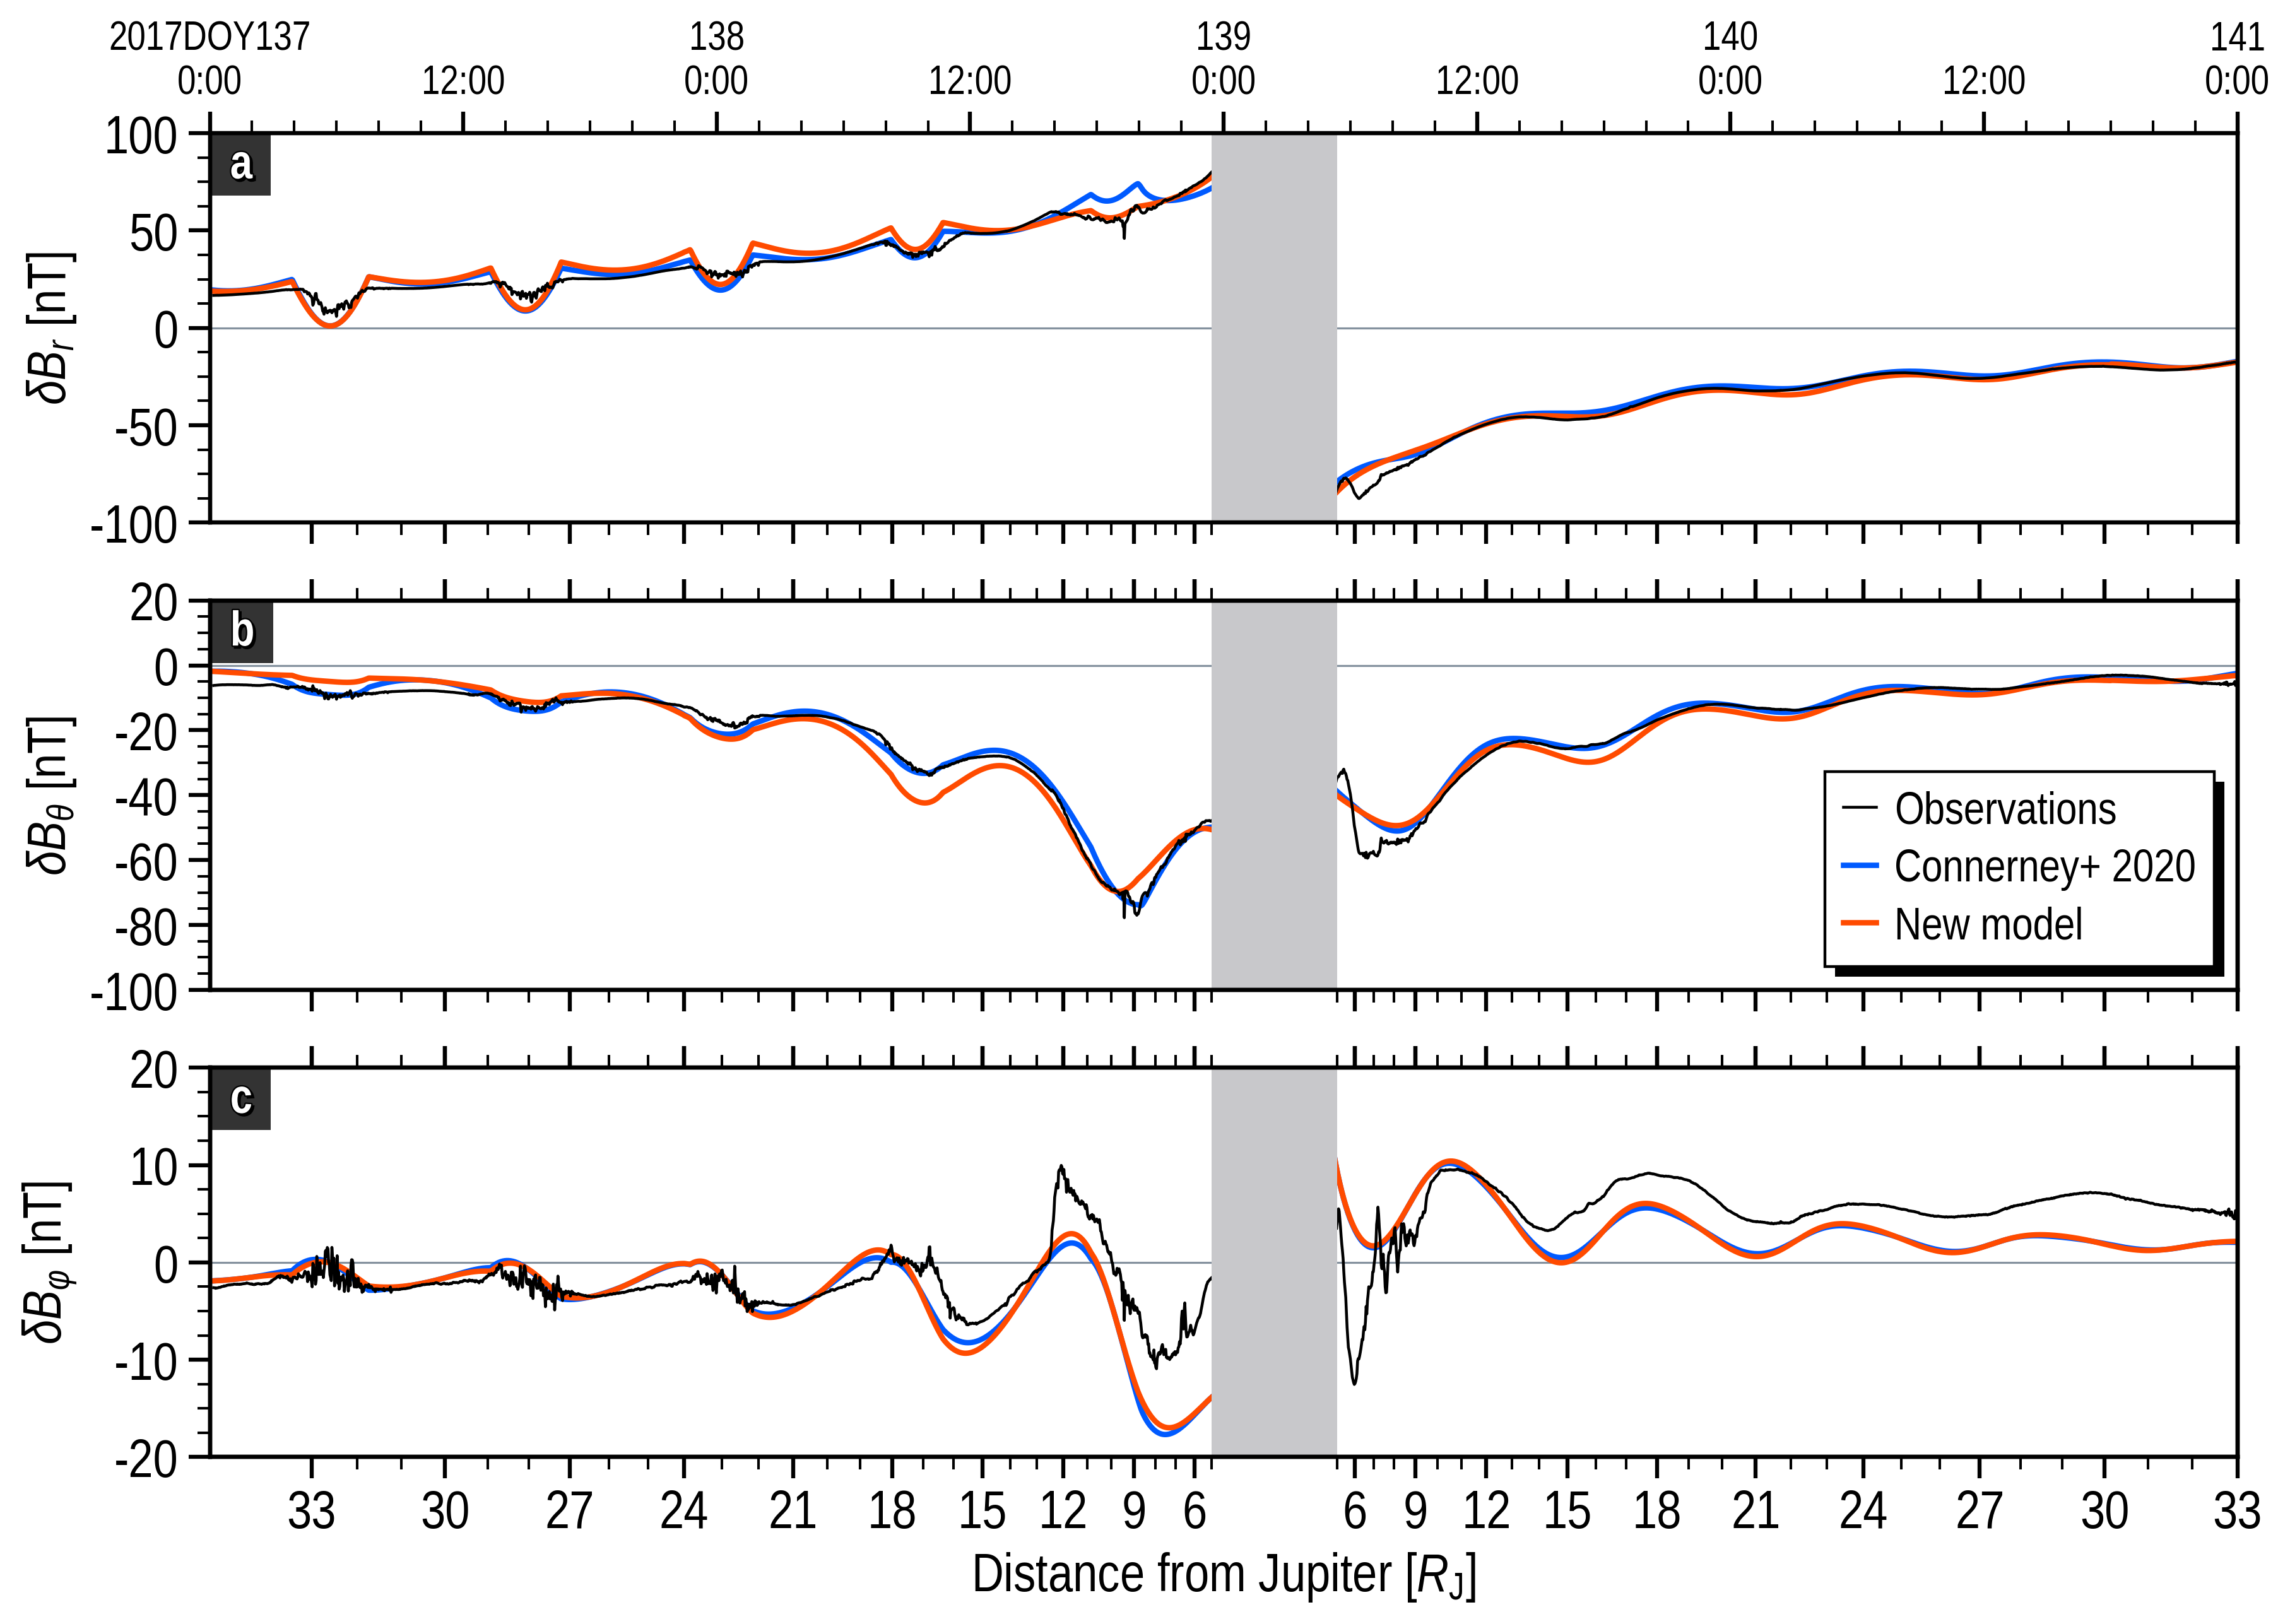

In [36]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=137.0, max=141.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(137.0, 141.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.9, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.9, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.9, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(137.0, 141.0)
timeax.set_xticks([137.0, 137.5, 138.0, 138.5,
                   139.0, 139.5, 140.0, 140.5,
                   141.0, ])
timeax.set_xticklabels([date_list[0]+'\n0:00', '12:00',
                        '138\n0:00', '12:00', '139\n0:00', '12:00',
                        '140\n0:00', '12:00', '141\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ3のデータを読み込む

In [37]:
PJ_num = 3
date_list = ['2016DOY344', '2016DOY345', '2016DOY346',
             '2016DOY347', '2016DOY348']

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

344.005219253 348.9996636973718
5.327339205789485 5.394686213997836


In [38]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

# ======================
# Con2020 original value
jm.Con2020.Config(
    mu_i=con20_mu_i_tot[np.where(con20_pj_idx == PJ_num)],
    i_rho=con20_mu_i_rho[np.where(con20_pj_idx == PJ_num)],
)
dBx1_pc = np.zeros(time_arr.size)
dBy1_pc = np.zeros(time_arr.size)
dBz1_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    dBx1_pc[i], dBy1_pc[i], dBz1_pc[i] = jm.Con2020.Field(rx_pc[i],
                                                          ry_pc[i],
                                                          rz_pc[i])  # [nT]
dBr1_pc = dBx1_pc*sin_theta*cos_phi + dBy1_pc * \
    sin_theta*sin_phi + dBz1_pc*cos_theta
dBtheta1_pc = dBx1_pc*cos_theta*cos_phi + \
    dBy1_pc*cos_theta*sin_phi - dBz1_pc*sin_theta
dBphi1_pc = -dBx1_pc*sin_phi + dBy1_pc*cos_phi

Distance [RJ]: 39.45912984948478 35.52482103483377


In [44]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 2.6E-4   # [MA m-1]
    csfield.config(
        I_rho=con20_mu_i_rho[np.where(con20_pj_idx == PJ_num)][0],
        I_phi=I_phi_0*f_i,
        D=3.0,
        c1=12.6,
        c2=20.7,
        c3=26.0,
        c4=45.0,
        w1=-0.20,
        w2=2.18,
        w3=-1.95,
        w4=0.29,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

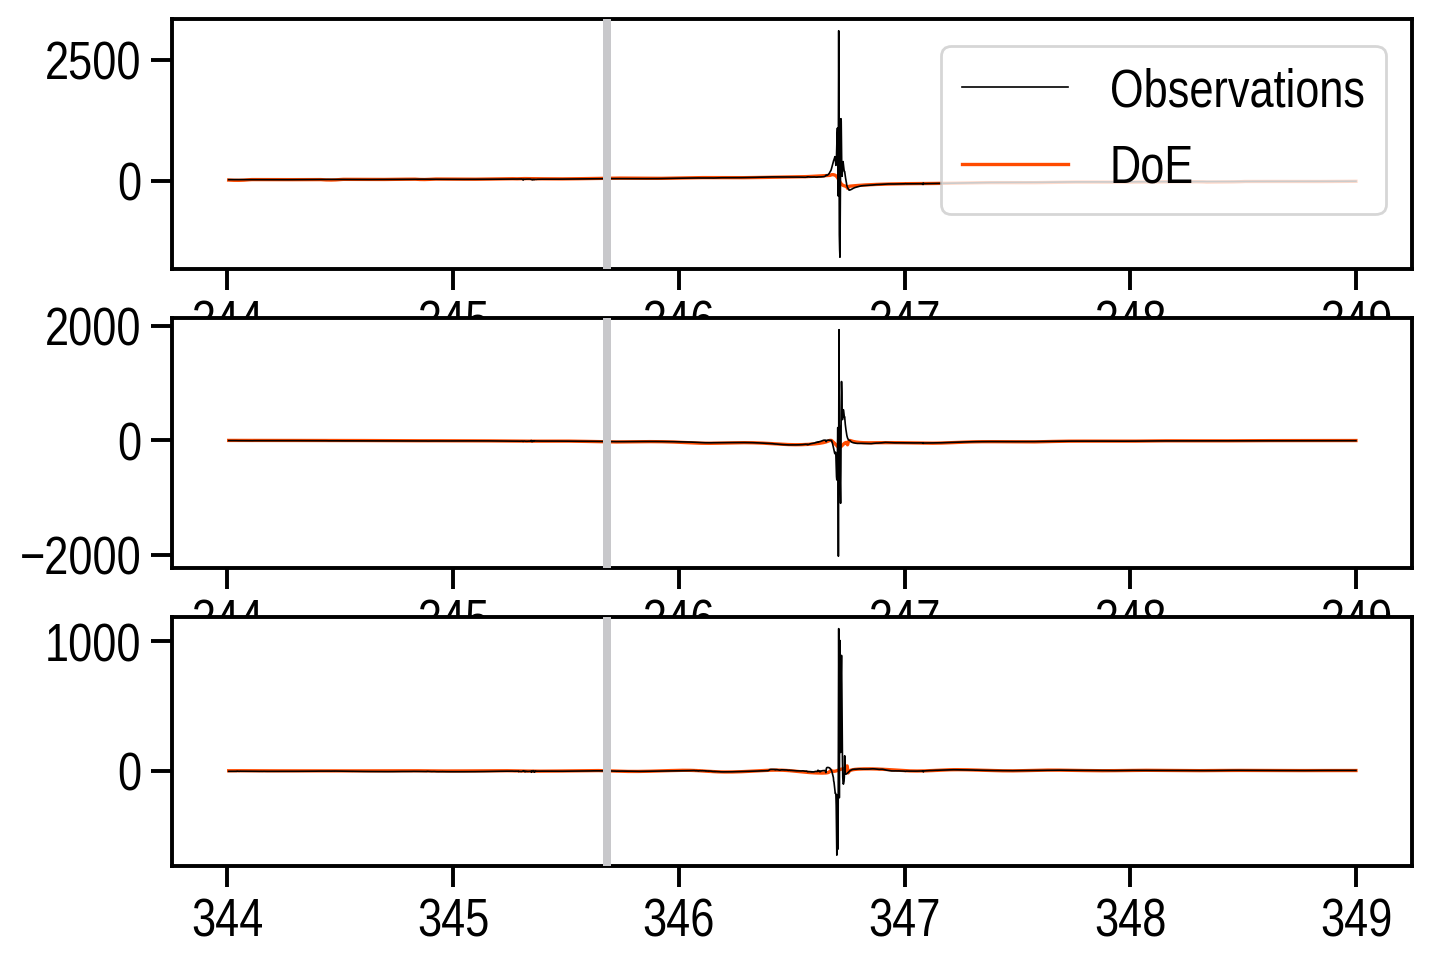

In [45]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), dpi=200)
ax[0].plot(time_arr, dBr, color='k',
           linewidth=0.6, label='Observations', zorder=2.0)
ax[0].plot(time_arr, dBr2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[1].plot(time_arr, dBtheta, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[2].plot(time_arr, dBphi, color='k',
           linewidth=0.6, label='Obs', zorder=2.0)
ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
           linewidth=1.2, label='DoE', zorder=1.0)
ax[0].legend()
for i in range(3):
    ax[i].axvspan(xmin=time_arr[1195], xmax=time_arr[1220],
                  facecolor=UC.lightgray, zorder=3)

In [46]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr1_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta1_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi1_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
3.19299495021117
6.610668658299514
1.8904732349999476
4.841937502406008
3.081660830152778
3.240943197674555
Outbound
4.715105758686772
3.122971500291167
1.5556294554108807


In [47]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(58, 2)
[ 32.         344.77049703]


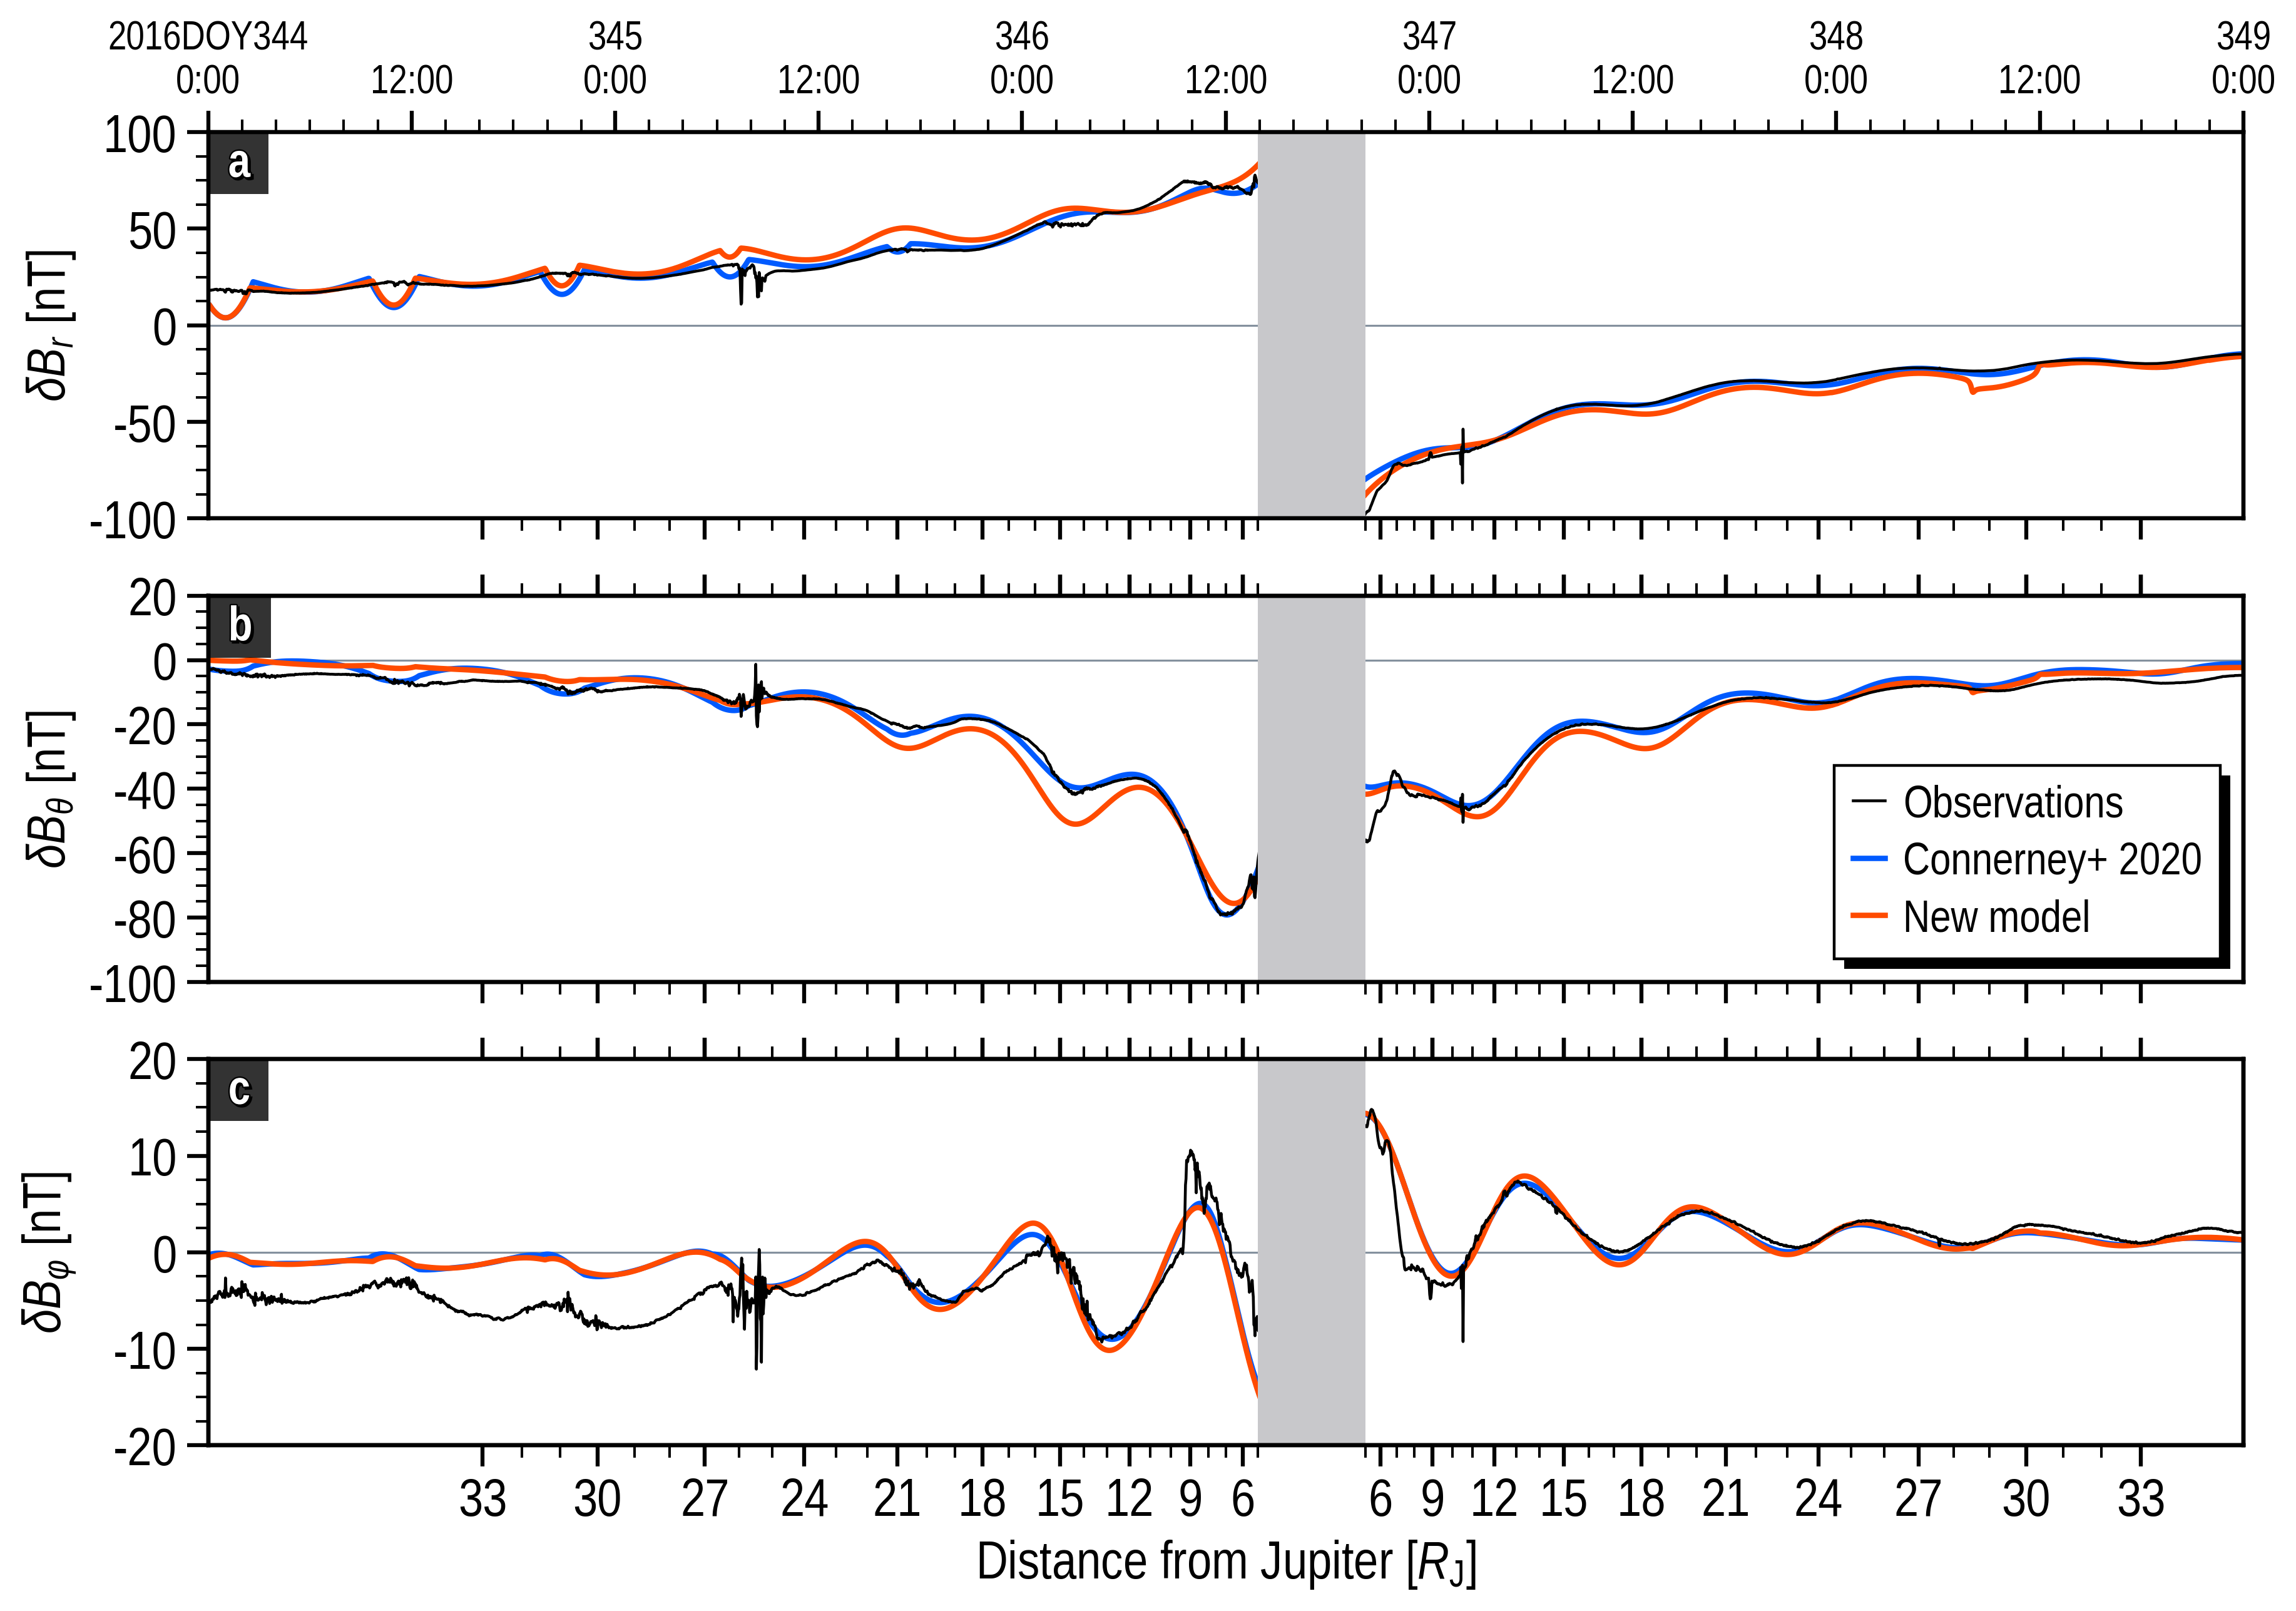

In [48]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=344.0, max=349.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(344.0, 349.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.9, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.9, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi1_pc, color=UC.blue,
             linewidth=1.9, label='Connerney+ 2020', zorder=1.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.9, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(344.0, 348.0)
timeax.set_xticks([344.0, 344.5, 345.0, 345.5, 346.0, 346.5,
                   347.0, 347.5, 348.0, 348.5,
                   349.0])
timeax.set_xticklabels([date_list[0]+'\n0:00', '12:00',
                        '345\n0:00', '12:00',
                        '346\n0:00', '12:00',
                        '347\n0:00', '12:00',
                        '348\n0:00', '12:00',
                        '349\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ12のデータを読み込む

In [79]:
PJ_num = 12
date_list = ['2018DOY089', '2018DOY090', '2018DOY091',
             '2018DOY092', '2018DOY093',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

89.006608501 93.9982751676451
2.9018520038918254 3.232870255181048


In [80]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

Distance [RJ]: 36.61609923365892 38.41655193796605


In [81]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 4.35E-4   # [MA m-1]
    csfield.config(
        I_rho=16.7,
        I_phi=I_phi_0*f_i,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [82]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
11.585766203889436
8.788203960217992
4.0015827889861715
Outbound
4.318106654776176
4.160037043028815
4.05294122641144


In [83]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(58, 2)
[32.         89.46771961]


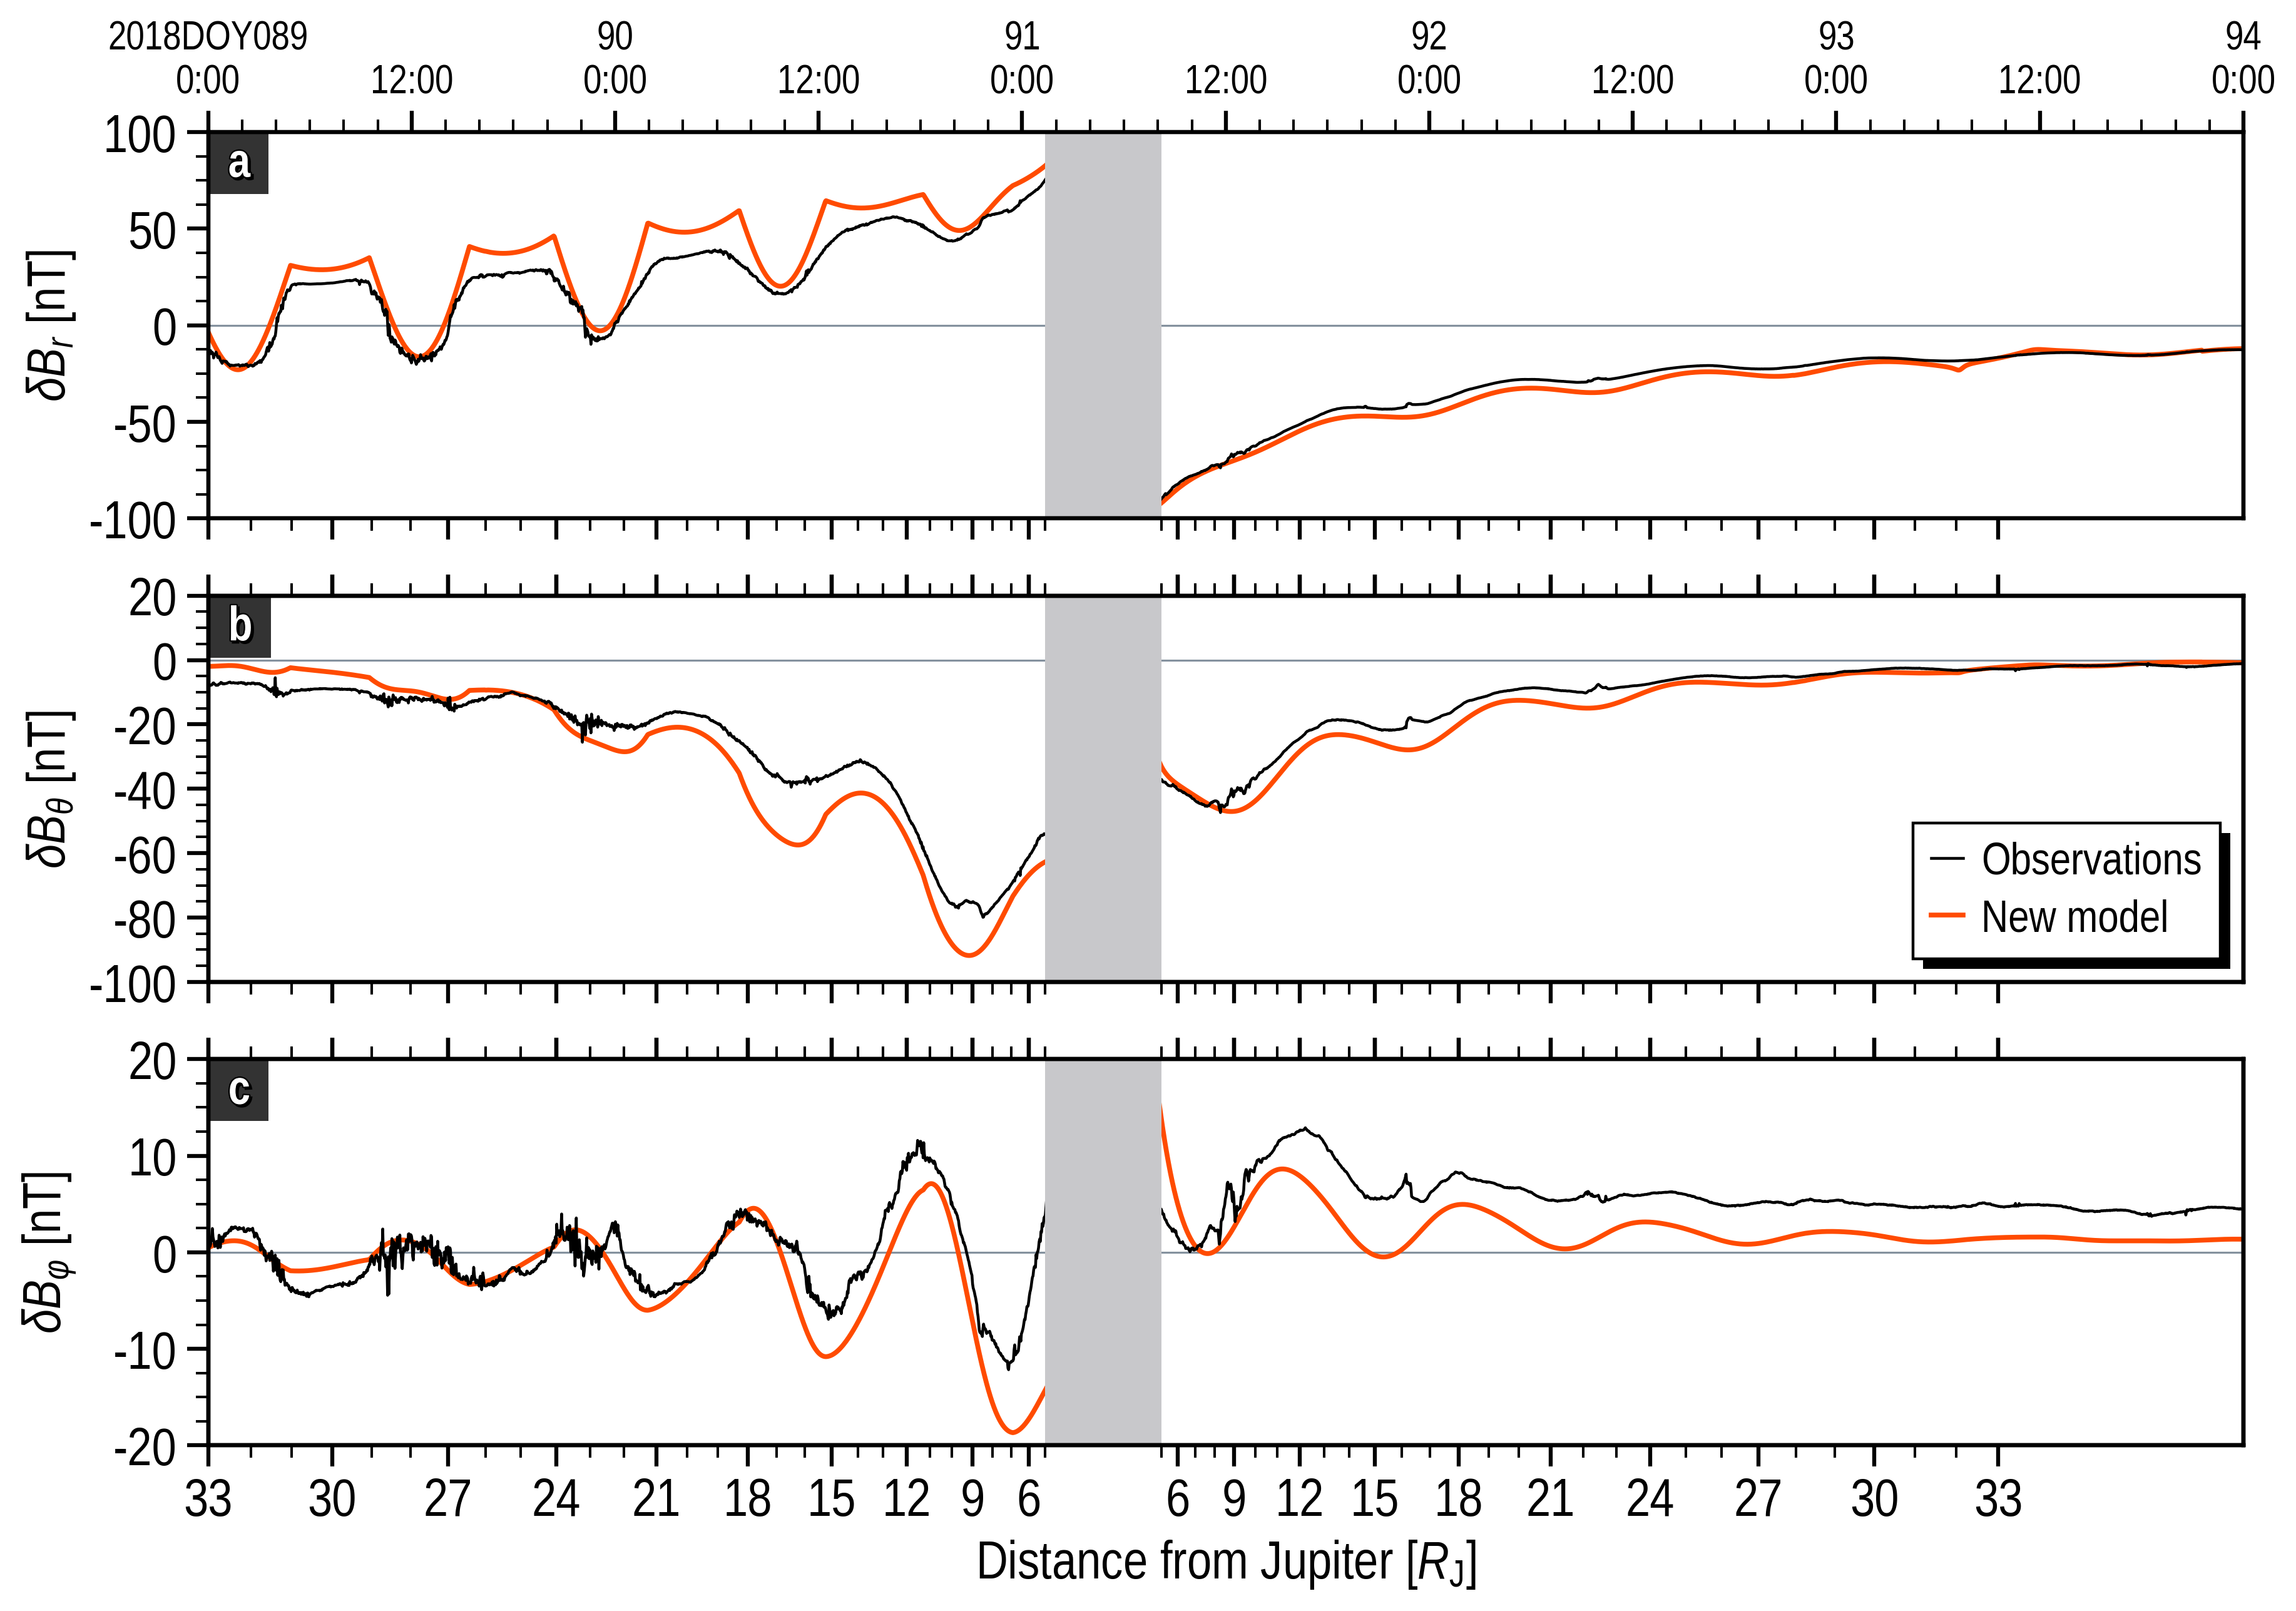

In [84]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=90.0, max=94.0,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(90.0, 94.0)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(89.0, 94.0)
timeax.set_xticks([89.0, 89.5, 90.0, 90.5, 91.0, 91.5,
                   92.0, 92.5, 93.0, 93.5,
                   94.0,])
timeax.set_xticklabels([date_list[0]+'\n0:00', '12:00',
                        '90\n0:00', '12:00',
                        '91\n0:00', '12:00', '92\n0:00', '12:00',
                        '93\n0:00', '12:00', '94\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ16のデータを読み込む

In [26]:
PJ_num = 16
day_min = 300
day_max = 304
date_list = ['2018DOY300', '2018DOY301', '2018DOY302',
             '2018DOY303', '2018DOY304',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

300.007986534 304.99826431170516
1.8795771802070966 2.3650489578366276


In [27]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

Distance [RJ]: 40.938896564876934 33.84365505092117


In [28]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 4.35E-4   # [MA m-1]
    csfield.config(
        I_rho=16.7,
        I_phi=I_phi_0*f_i,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [29]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
6.643135200037849
7.103665526724421
3.942301075476216
Outbound
2.3148355539303913
2.1944107537458146
1.2589248251437386


In [30]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(58, 2)
[ 32.         300.93993098]


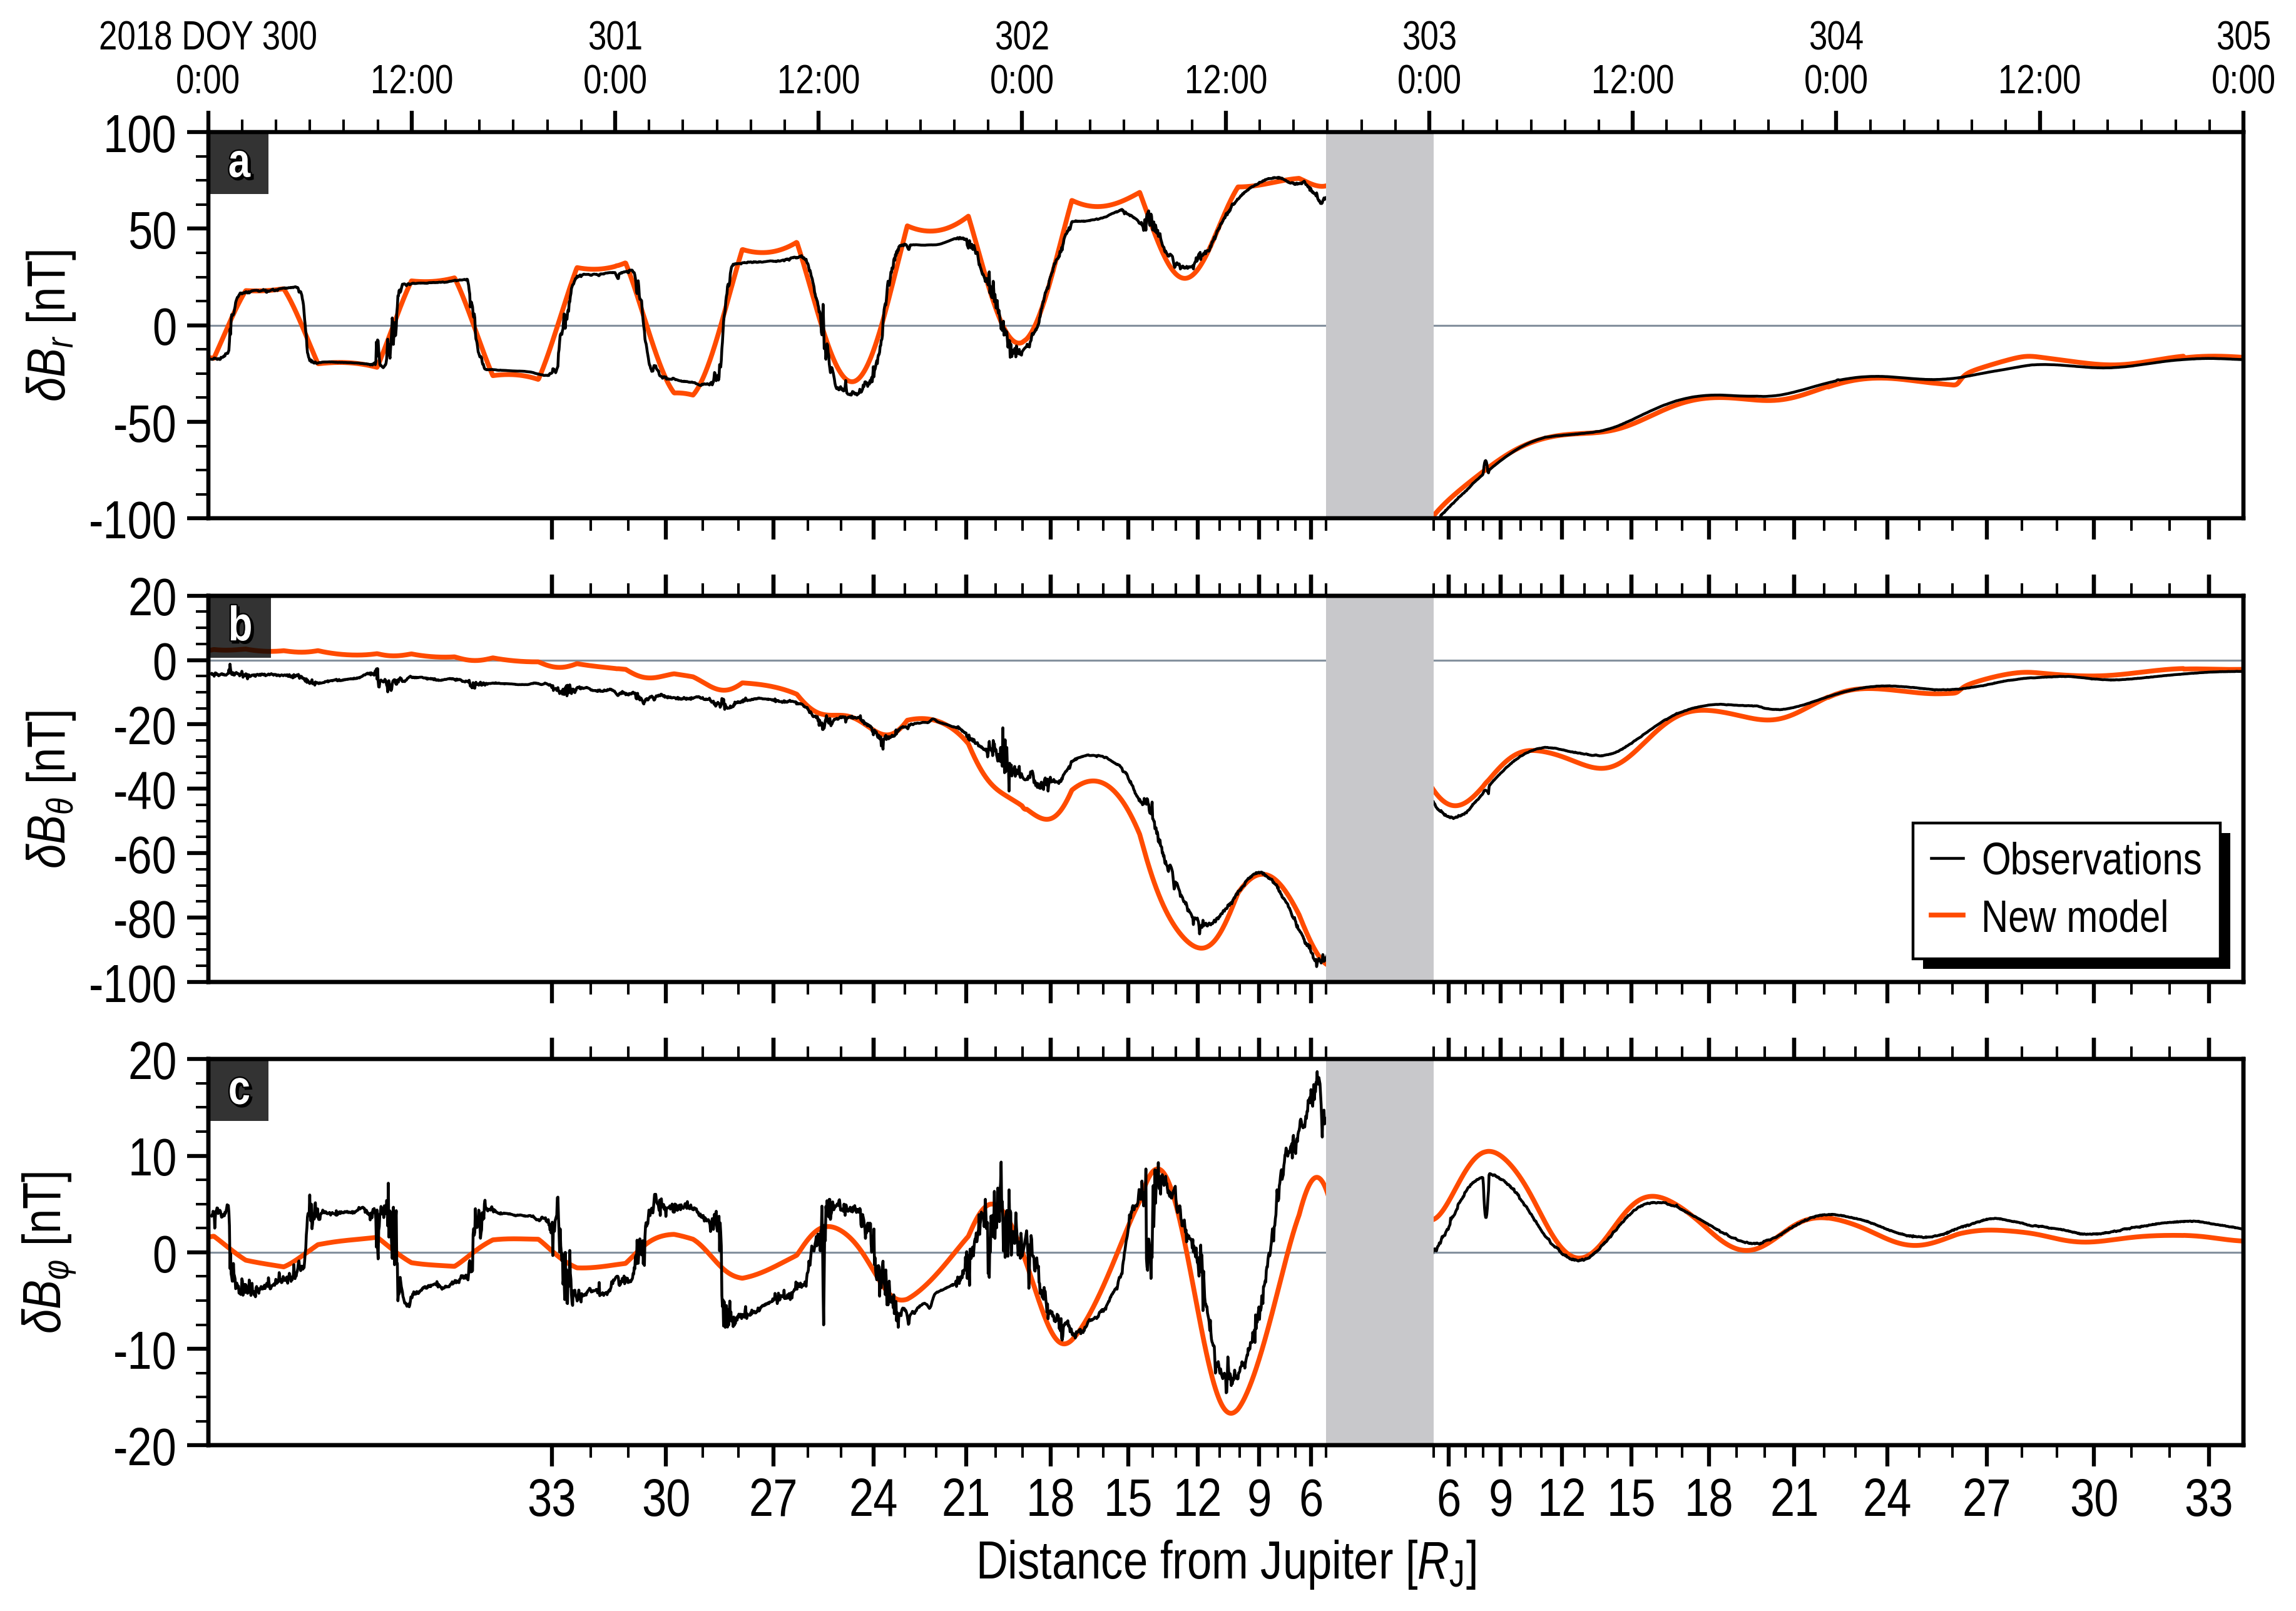

In [31]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=day_min, max=day_max+1,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(day_min, day_max+1)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(day_min, day_min+1)
timeax.set_xticks([300.0, 300.5, 301.0, 301.5,
                   302.0, 302.5, 303.0, 303.5,
                   304.0, 304.5,
                   305.0])
timeax.set_xticklabels(['2018 DOY 300\n0:00', '12:00',
                        '301\n0:00', '12:00',
                        '302\n0:00', '12:00', '303\n0:00', '12:00',
                        '304\n0:00', '12:00', '305\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ17のデータを読み込む

In [32]:
PJ_num = 17
day_min = 353
day_max = 357
date_list = ['2018DOY353', '2018DOY354', '2018DOY355',
             '2018DOY356', '2018DOY357',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

353.008691603 357.99896938070515
1.6146303191996836 2.1306125347056195


In [33]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

Distance [RJ]: 39.38501193650486 35.54028105316963


In [34]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 4.35E-4   # [MA m-1]
    csfield.config(
        I_rho=16.7,
        I_phi=I_phi_0*f_i,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [35]:
print(np.min(r_pc))

5.405681714802017


In [36]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 8.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 8.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
10.426265790878738
10.790413665916997
2.619553964508926
Outbound
4.49735949930411
2.8813776220848966
1.2501000625432104


In [37]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(8, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(52, 2)
[ 32.         353.76702494]


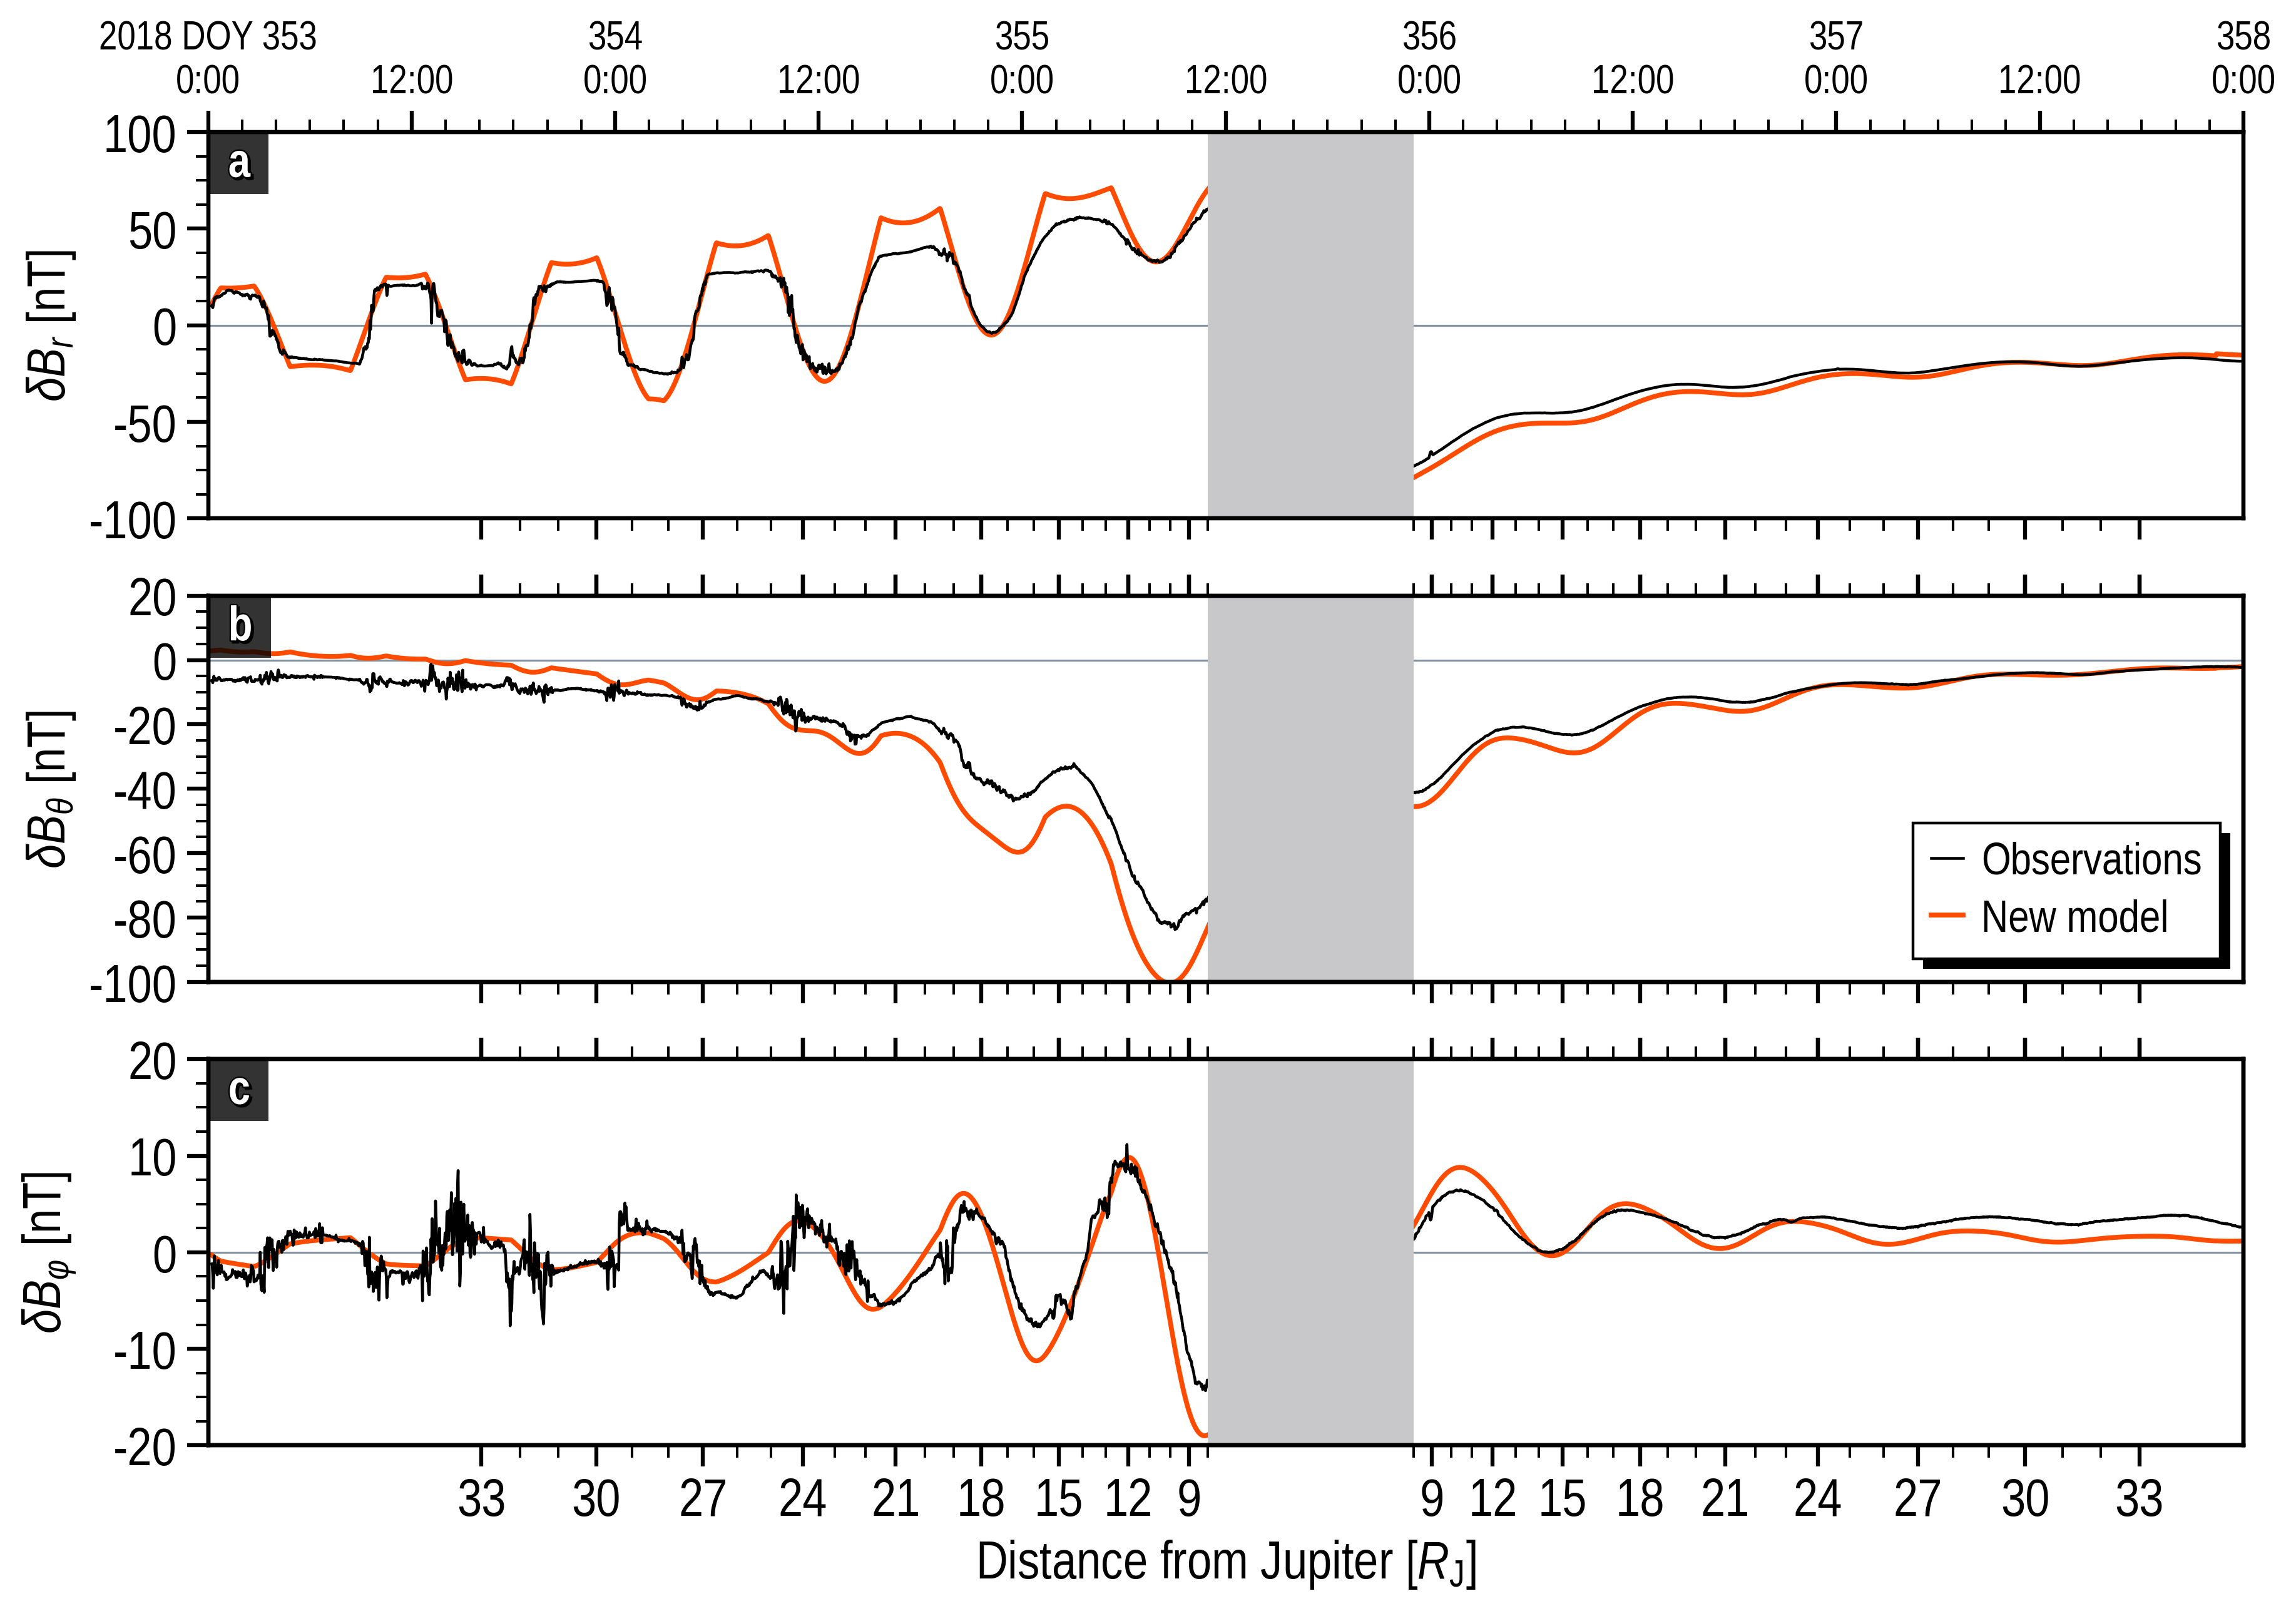

In [38]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=day_min, max=day_max+1,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(day_min, day_max+1)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 8.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(day_min, day_min+1)
timeax.set_xticks([353.0, 353.5, 354.0, 354.5,
                   355.0, 355.5, 356.0, 356.5,
                   357.0, 357.5,
                   358.0])
timeax.set_xticklabels(['2018 DOY 353\n0:00', '12:00',
                        '354\n0:00', '12:00',
                        '355\n0:00', '12:00', '356\n0:00', '12:00',
                        '357\n0:00', '12:00', '358\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ04のデータを読み込む

In [39]:
PJ_num = 4
day_min = 31
day_max = 35
date_list = ['2017DOY031', '2017DOY032', '2017DOY033',
             '2017DOY034', '2017DOY035',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

31.006609277 35.998275943670635
5.055996304793137 5.1384209029312515


In [40]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

Distance [RJ]: 37.864689037918076 37.16067831019074


In [41]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 4.35E-4   # [MA m-1]
    csfield.config(
        I_rho=16.7,
        I_phi=I_phi_0*f_i,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [42]:
print(np.min(r_pc))

1.059210848517443


In [43]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
6.495832881950854
4.227135480273627
3.3439440926152293
Outbound
3.865494154369796
2.942319025736485
2.00194839286159


In [44]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(58, 2)
[32.         31.59966483]


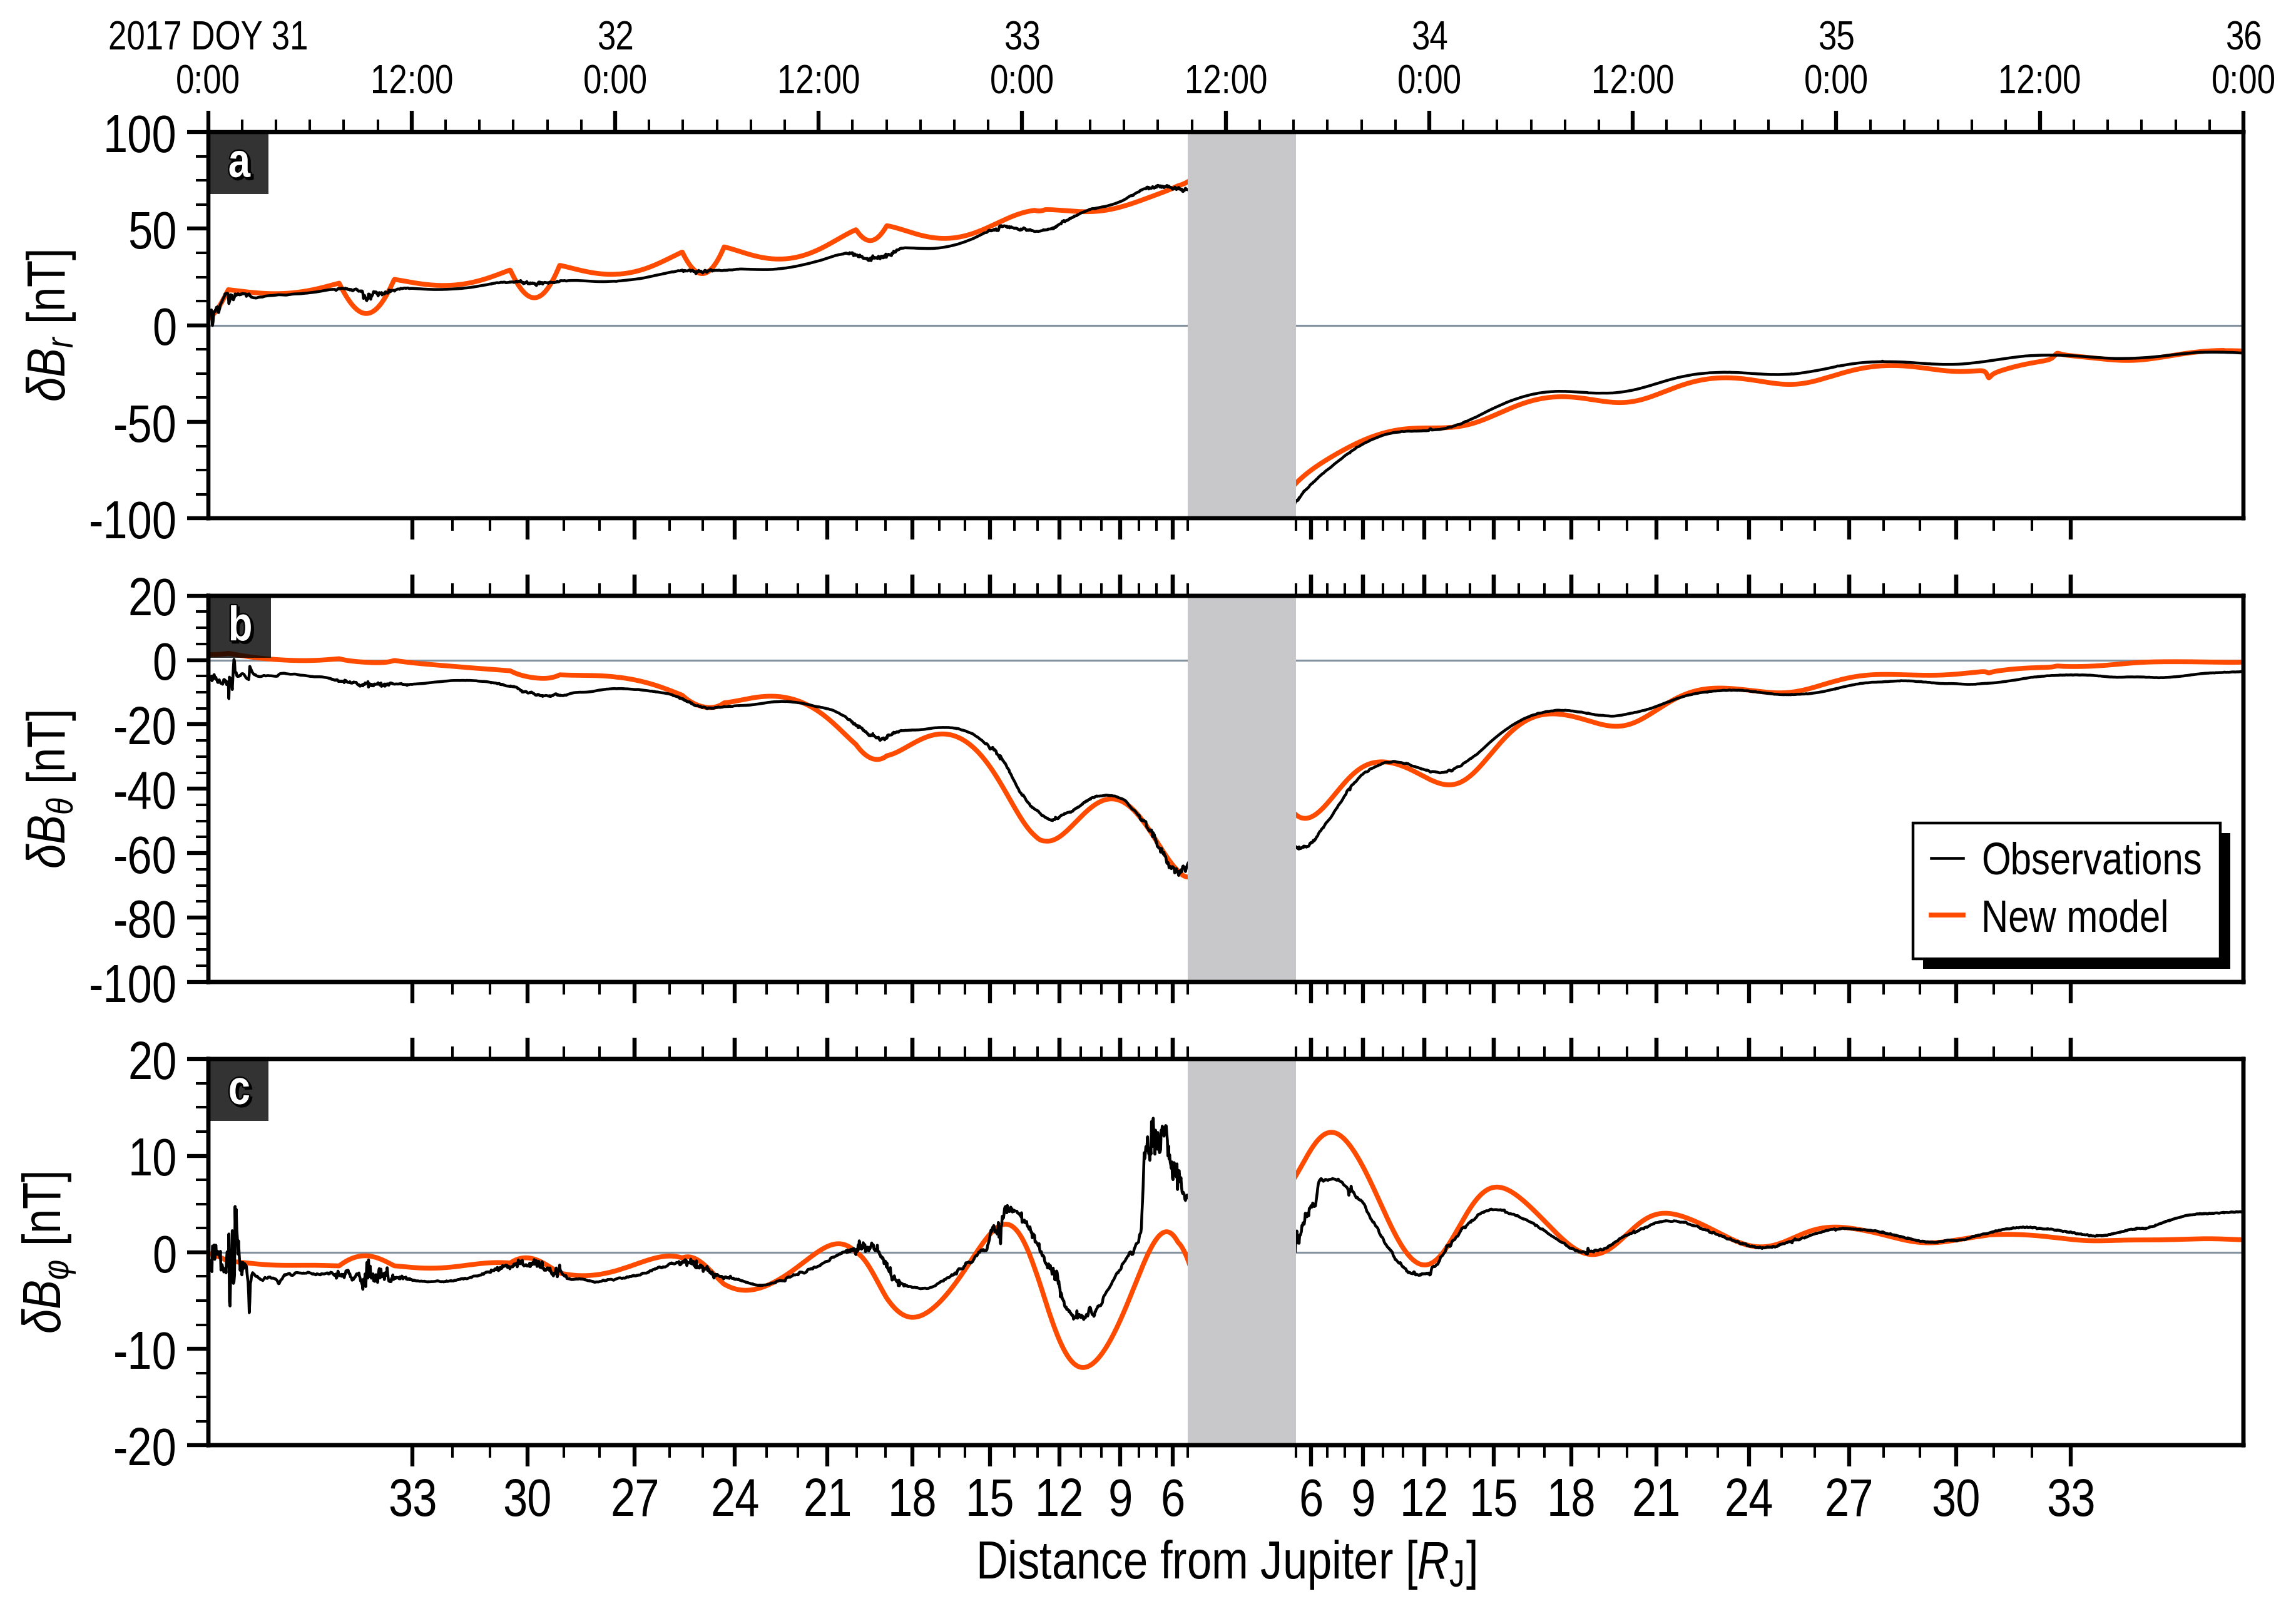

In [45]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=day_min, max=day_max+1,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(day_min, day_max+1)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(day_min, day_max+1)
timeax.set_xticks(np.arange(day_min, day_max+1+0.1, 0.5))
timeax.set_xticklabels(['2017 DOY 31\n0:00', '12:00',
                        '32\n0:00', '12:00',
                        '33\n0:00', '12:00', '34\n0:00', '12:00',
                        '35\n0:00', '12:00', '36\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ05のデータを読み込む

In [46]:
PJ_num = 5
day_min = 84
day_max = 88
date_list = ['2017DOY084', '2017DOY085', '2017DOY086',
             '2017DOY087', '2017DOY088',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

84.007303145 88.9989698116451
4.785349610584138 4.886933405550266


In [47]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

Distance [RJ]: 36.249266631598424 38.77305618899581


In [48]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 4.35E-4   # [MA m-1]
    csfield.config(
        I_rho=16.7,
        I_phi=I_phi_0*f_i,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [49]:
print(np.min(r_pc))

1.046445094340985


In [50]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
6.146748651925702
4.391945334119022
4.036457791012854
Outbound
3.768009933308489
2.965916015068588
2.23972422825703


In [51]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 33+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(58, 2)
[32.         84.42952537]


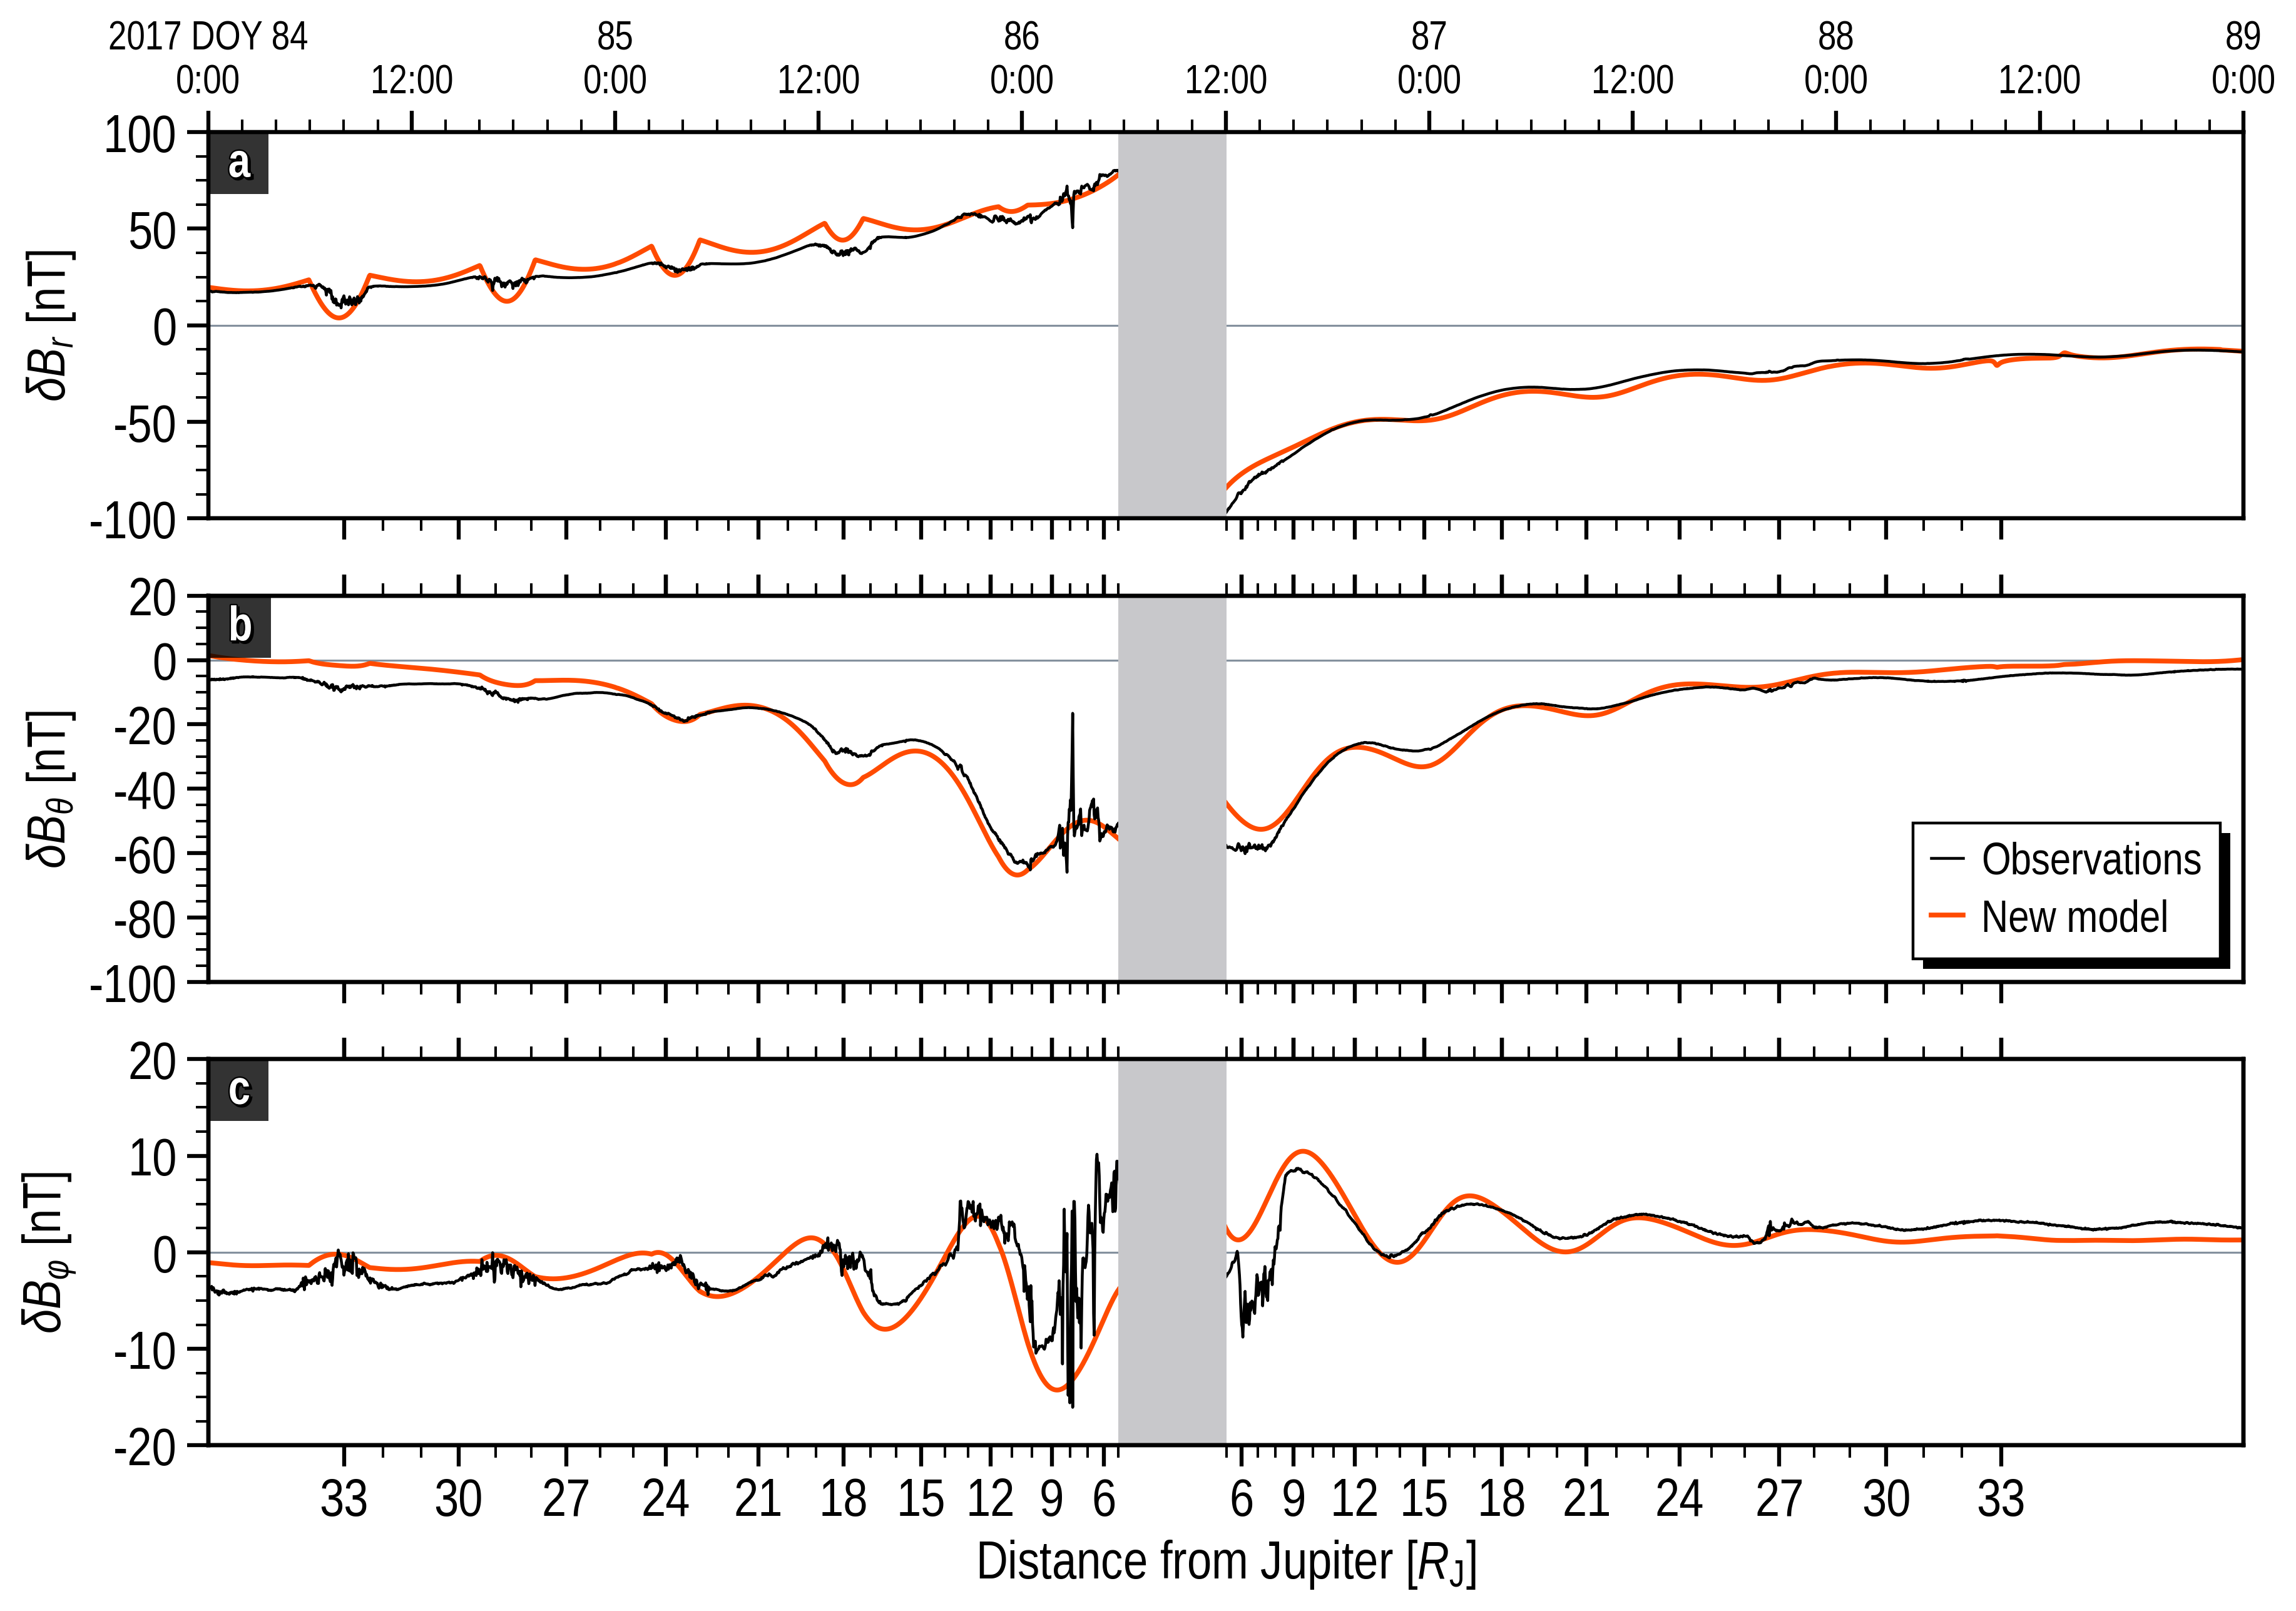

In [52]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=day_min, max=day_max+1,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(day_min, day_max+1)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(day_min, day_max+1)
timeax.set_xticks(np.arange(day_min, day_max+1+0.1, 0.5))
timeax.set_xticklabels(['2017 DOY 84\n0:00', '12:00',
                        '85\n0:00', '12:00',
                        '86\n0:00', '12:00', '87\n0:00', '12:00',
                        '88\n0:00', '12:00', '89\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)

# PJ07のデータを読み込む

In [53]:
PJ_num = 7
day_min = 190
day_max = 193
date_list = ['2017DOY190', '2017DOY191', '2017DOY192',
             '2017DOY193',]

dir = 'data/FGM/PJ'+str(PJ_num).zfill(2)+'/'
time_arr = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_time.txt')
Bx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bx.txt')
By_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_By.txt')
Bz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_Bz.txt')
rx_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rx.txt')
ry_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_ry.txt')
rz_pc = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_rz.txt')
JunoMLT = np.loadtxt(dir+'fgm_PJ'+str(PJ_num).zfill(2)+'_pc_2min_JunoMLT.txt')

rx_pc *= 1/71492.0  # [RJ]
ry_pc *= 1/71492.0  # [RJ]
rz_pc *= 1/71492.0  # [RJ]

print(time_arr[0], time_arr[-1])
print(JunoMLT[0], JunoMLT[-1])

190.008692633 193.99897041080138
4.236834503266422 4.4166436767559425


In [54]:
# 座標
r_pc = np.sqrt(rx_pc**2+ry_pc**2+rz_pc**2)
cos_phi = rx_pc/r_pc
sin_phi = ry_pc/r_pc
cos_theta = rz_pc/r_pc
sin_theta = np.sqrt(rx_pc**2+ry_pc**2)/r_pc
print('Distance [RJ]:', r_pc[0], r_pc[-1])

# ==============
# Internal field
Bx0_pc = np.zeros(time_arr.size)
By0_pc = np.zeros(time_arr.size)
Bz0_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    Bx0_pc[i], By0_pc[i], Bz0_pc[i] = jm.Internal.Field(rx_pc[i],
                                                        ry_pc[i],
                                                        rz_pc[i])  # [nT]
dBx = Bx_pc - Bx0_pc
dBy = By_pc - By0_pc
dBz = Bz_pc - Bz0_pc
dBr = dBx*sin_theta*cos_phi + dBy*sin_theta*sin_phi + dBz*cos_theta
dBtheta = dBx*cos_theta*cos_phi + dBy*cos_theta*sin_phi - dBz*sin_theta
dBphi = -dBx*sin_phi + dBy*cos_phi

Distance [RJ]: 33.35659887668871 31.7763282467075


In [55]:
# =========
# DoE model
csfield = CSField()

dBx2_pc = np.zeros(time_arr.size)
dBy2_pc = np.zeros(time_arr.size)
dBz2_pc = np.zeros(time_arr.size)
for i in range(time_arr.size):
    MLT0 = 21.51    # [hr]
    f_i = 1+0.17*math.cos(2*np.pi*(JunoMLT[i]-MLT0)/24.0)
    I_phi_0 = 4.38E-4   # [MA m-1]
    csfield.config(
        I_rho=16.7,
        I_phi=I_phi_0*f_i,
    )
    dBx2_pc[i], dBy2_pc[i], dBz2_pc[i] = csfield.magnetic_field(rx_pc[i],
                                                                ry_pc[i],
                                                                rz_pc[i])  # [T]
dBx2_pc *= 1E+9    # [nT]
dBy2_pc *= 1E+9    # [nT]
dBz2_pc *= 1E+9    # [nT]
dBr2_pc = dBx2_pc*sin_theta*cos_phi + dBy2_pc * \
    sin_theta*sin_phi + dBz2_pc*cos_theta
dBtheta2_pc = dBx2_pc*cos_theta*cos_phi + \
    dBy2_pc*cos_theta*sin_phi - dBz2_pc*sin_theta
dBphi2_pc = -dBx2_pc*sin_phi + dBy2_pc*cos_phi

In [56]:
print(np.min(r_pc))

1.0469453550261594


In [57]:
# RMSE（Root Mean Squared Error: 二乗平均平方根誤差）
in_30rj = np.where(r_pc < 30.0)[0][0]
in_5rj = np.where(r_pc < 5.0)[0][0]
in_num = in_5rj-in_30rj-1
out_30rj = np.where(r_pc < 30.0)[0][-1]
out_5rj = np.where(r_pc < 5.0)[0][-1]
out_num = out_30rj-out_5rj-1

print('Inbound')
print(
    math.sqrt(
        np.sum((dBr[in_30rj:in_5rj]-dBr2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[in_30rj:in_5rj]-dBtheta2_pc[in_30rj:in_5rj])**2)/in_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[in_30rj:in_5rj]-dBphi2_pc[in_30rj:in_5rj])**2)/in_num
    )
)

print('Outbound')
print(
    math.sqrt(
        np.sum((dBr[out_5rj:out_30rj]-dBr2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBtheta[out_5rj:out_30rj] -
               dBtheta2_pc[out_5rj:out_30rj])**2)/out_num
    )
)
print(
    math.sqrt(
        np.sum((dBphi[out_5rj:out_30rj] -
               dBphi2_pc[out_5rj:out_30rj])**2)/out_num
    )
)

Inbound
5.649969355910706
4.046944868373397
3.935377085277725
Outbound
3.1890539540836356
3.1443846587000785
1.9575157734504811


In [58]:
in_edge = int(r_pc.size/2)
r_ticks_ref = np.arange(5, 30+1, 1)
r_ticks = np.zeros((r_ticks_ref.size*2, 2))
for i in range(r_ticks_ref.size):
    r_i = r_ticks_ref[-1]-i
    time_i = time_arr[np.where(r_pc < r_i)[0][0]]
    r_ticks[i, 0] = r_i
    r_ticks[i, 1] = time_i

    time_i = time_arr[np.where(r_pc < r_i)[0][-1]]
    r_ticks[-i-1, 0] = r_i
    r_ticks[-i-1, 1] = time_i

print(r_ticks.shape)
print(r_ticks[1, :])

(52, 2)
[ 29.         190.41563708]


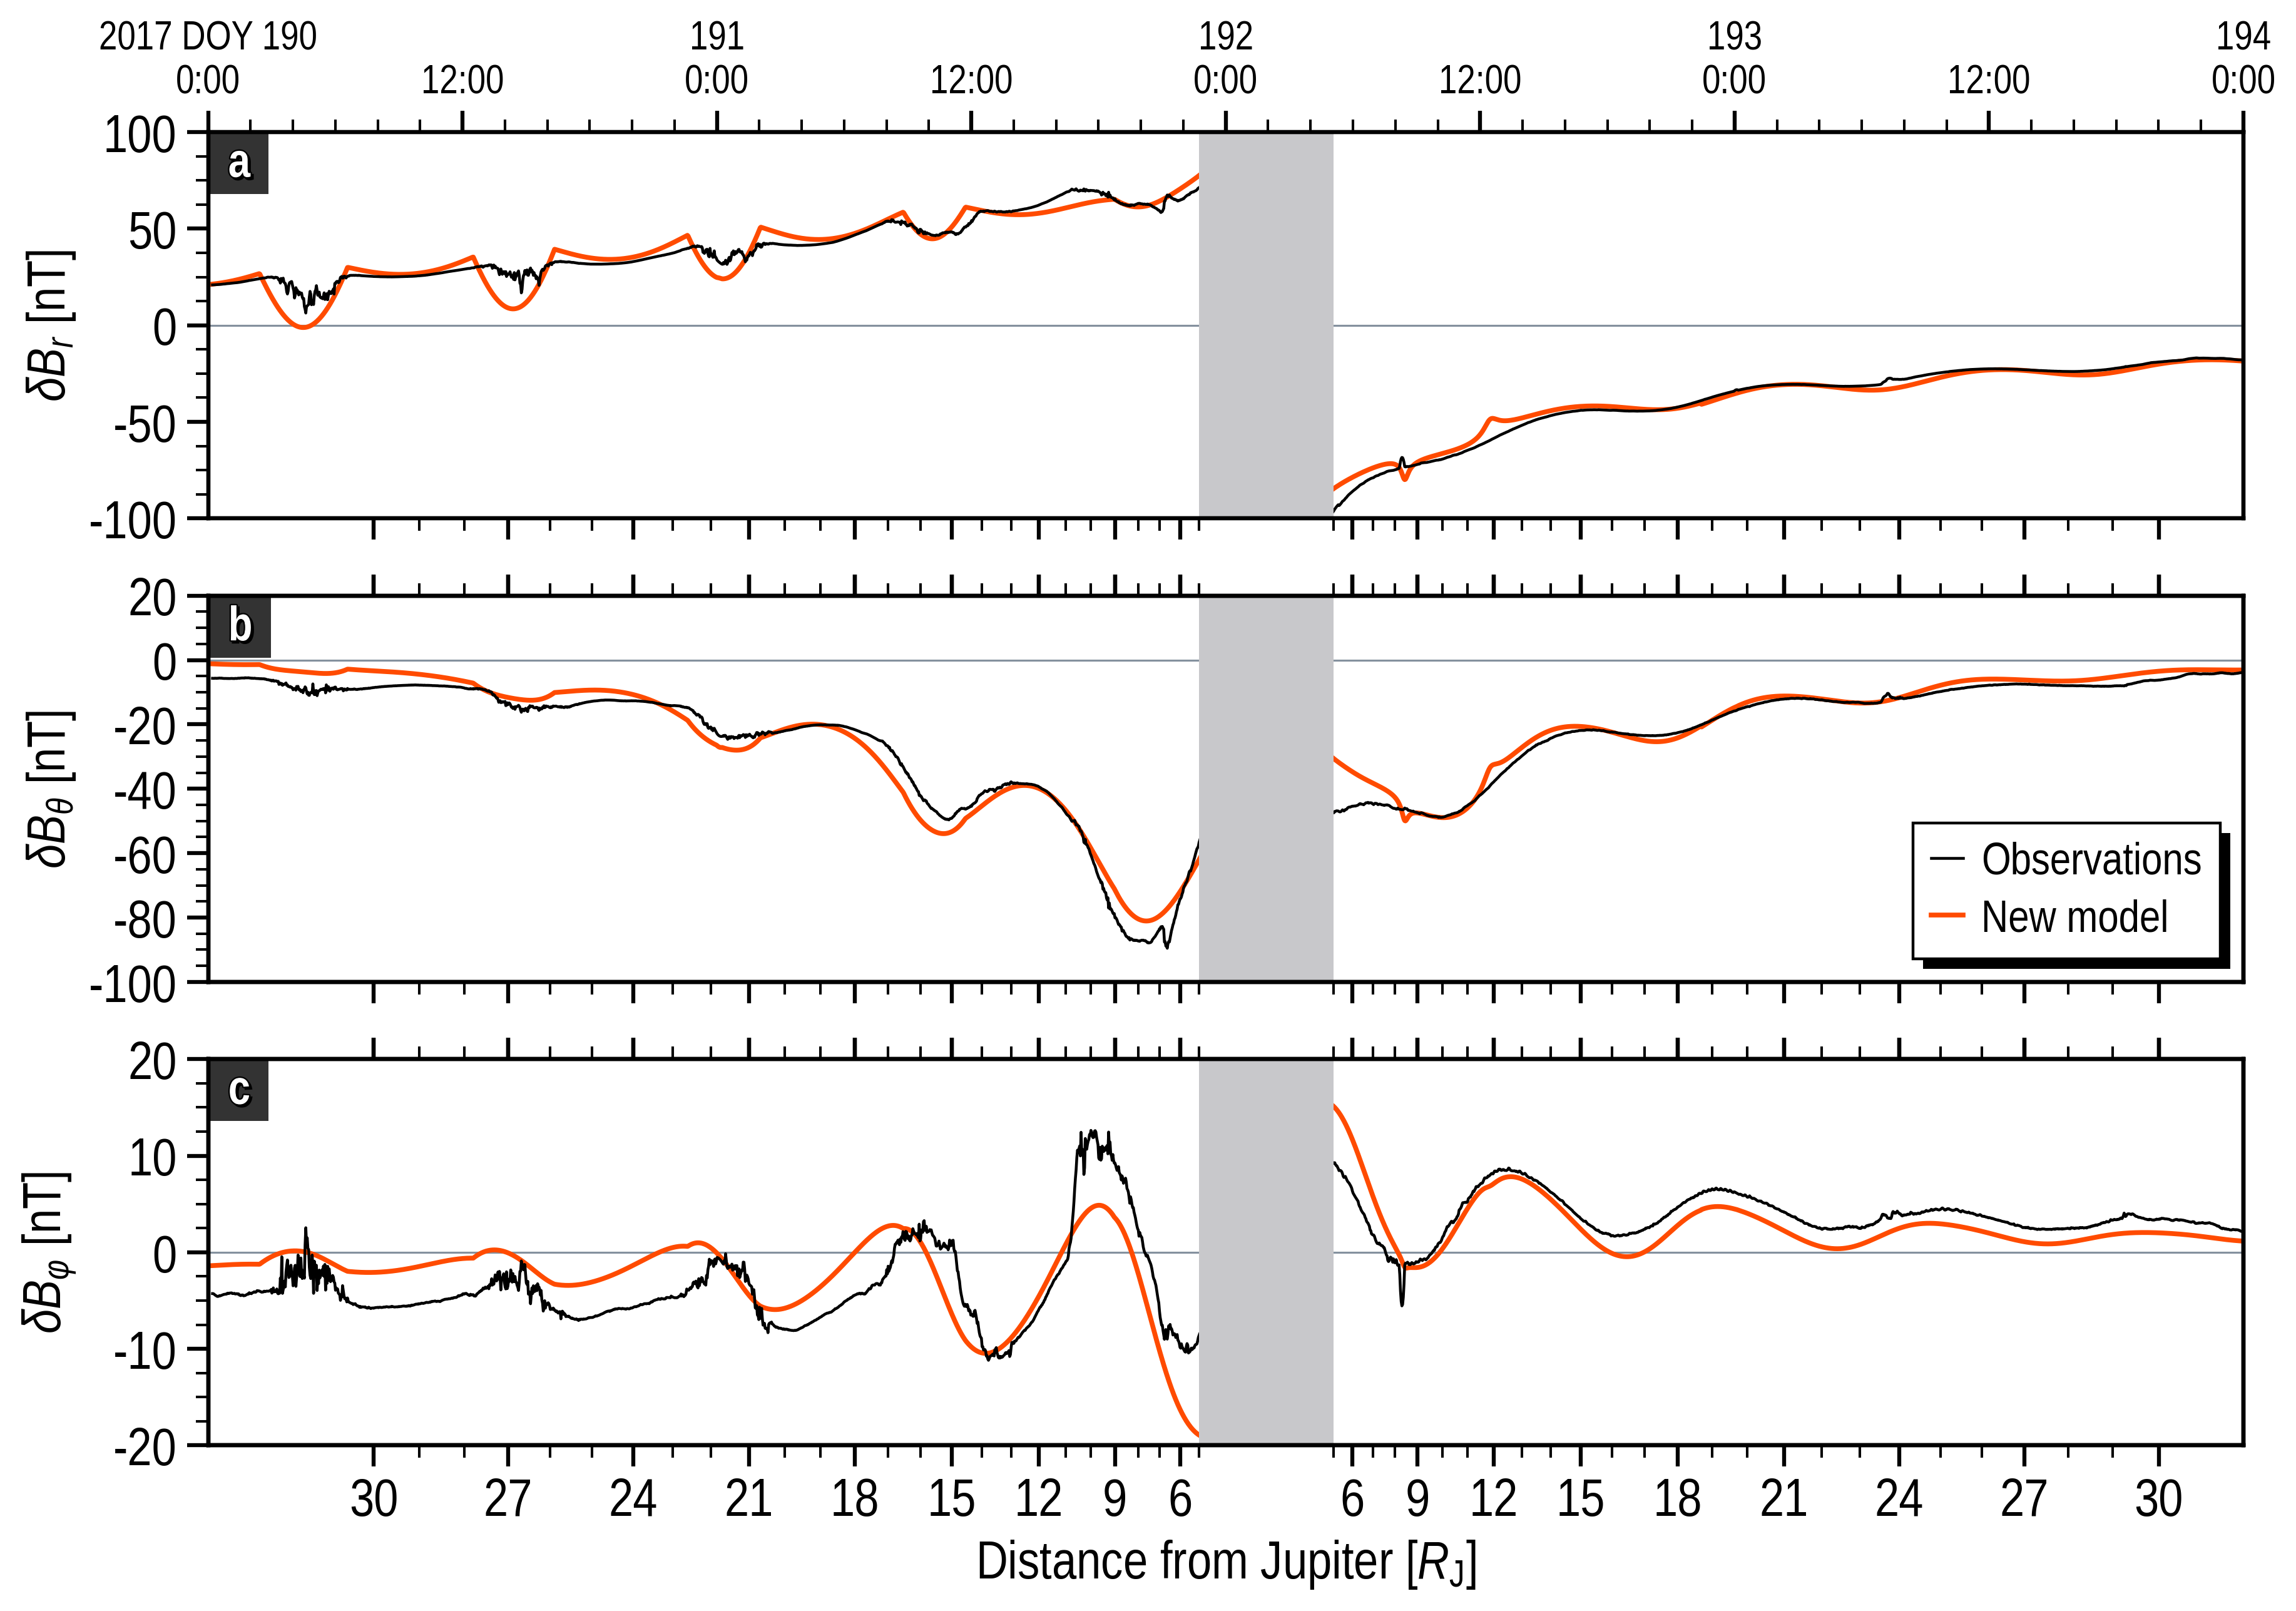

In [59]:
F = ShareXaxis()
F.fontsize = 19
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=3, figsize=(11.0, 7.5), dpi='XL')
F.hspace = 0.2
F.initialize()

xticks = r_ticks[::3, 1]
xticklabels = r_ticks[::3, 0].astype(int)

F.set_xaxis(label=r'Distance from Jupiter [$R_{\rm J}$]',
            min=day_min, max=day_max+1,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=None)
for i in range(3):
    F.ax[i].xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
for i in range(2):
    i += 1
    ax_upper = F.ax[i].twiny()
    ax_upper.set_xlim(day_min, day_max+1)
    ax_upper.set_xticks(xticks)
    ax_upper.xaxis.set_minor_locator(FixedLocator(r_ticks[:, 1]))
    ax_upper.tick_params(labeltop=False)

F.set_yaxis(ax_idx=0,
            label=r'$\delta B_{r}$ [nT]',
            min=-100, max=100,
            ticks=np.linspace(-100, 100, 5),
            ticklabels=np.linspace(-100, 100, 5, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=1,
            label=r'$\delta B_{\theta}$ [nT]',
            min=-100, max=20,
            ticks=np.linspace(-100, 20, 7),
            ticklabels=np.linspace(-100, 20, 7, dtype=int),
            minor_num=4)
F.set_yaxis(ax_idx=2,
            label=r'$\delta B_{\varphi}$ [nT]',
            min=-20, max=20,
            ticks=np.linspace(-20, 20, 5),
            ticklabels=np.linspace(-20, 20, 5, dtype=int),
            minor_num=4)
F.ax[0].plot(time_arr, dBr, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[0].plot(time_arr, dBr2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[1].plot(time_arr, dBtheta, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[1].plot(time_arr, dBtheta2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)
F.ax[2].plot(time_arr, dBphi, color='k',
             linewidth=1.0, label='Observations', zorder=2.0)
F.ax[2].plot(time_arr, dBphi2_pc, color=UC.red,
             linewidth=1.7, label='New model', zorder=1.0)

# Shades near Jupiter (< 5.0 RJ)
inner_idx = np.where((r_pc < 5.0))[0]
for i in range(F.nrows):
    F.ax[i].axvspan(time_arr[inner_idx[0]],
                    time_arr[inner_idx[-1]],
                    fc=UC.lightgray, ec=None, zorder=2.5)

# y = 0 line
for i in range(F.nrows):
    F.ax[i].axhline(y=0.0, color=UC.gray, linewidth=0.7, zorder=0.9)

# Time axis
timeax = F.ax[0].twiny()
timeax.set_xlim(day_min, day_max+1)
timeax.set_xticks(np.arange(day_min, day_max+1+0.1, 0.5))
timeax.set_xticklabels(['2017 DOY 190\n0:00', '12:00',
                        '191\n0:00', '12:00',
                        '192\n0:00', '12:00', '193\n0:00', '12:00',
                        '194\n0:00',], fontsize=F.fontsize*0.75)
timeax.xaxis.set_minor_locator(ptick.AutoMinorLocator(6))

legend = F.legend(ax_idx=1,
                  ncol=1, markerscale=1.0,
                  loc='lower right',
                  handlelength=0.7,
                  textcolor=False,
                  fontsize_scale=0.85,
                  handletextpad=0.4)
legend_shadow(legend=legend, fig=F.fig, ax=F.ax[0], d=0.7)